In [1]:
import math
import numpy as np
import pandas as pd
import copy
import re
import ast
from collections import Counter, defaultdict
from itertools import combinations
from numpy.linalg import det
from tqdm import tqdm
from scipy.stats import chi2
from statsmodels.stats.contingency_tables import mcnemar

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Load Initial Policy CSVs and Perform Data Processing

In [3]:
# load all CSVs
temp_df_qwen = pd.read_csv('InitialPolicyData/botdetect_policy_df_Qwen25_7B.csv')
temp_df_mistral = pd.read_csv('InitialPolicyData/botdetect_policy_df_Mistral_7B.csv')
temp_df_gemma = pd.read_csv('InitialPolicyData/botdetect_policy_df_gemma_7b.csv')
temp_df_yi = pd.read_csv('InitialPolicyData/botdetect_policy_df_Yi_9B.csv')
temp_df_granite = pd.read_csv('InitialPolicyData/botdetect_policy_df_granite_8b.csv')
temp_df_zephyr = pd.read_csv('InitialPolicyData/botdetect_policy_df_zephyr_7B.csv')
temp_df_deepseek_llm = pd.read_csv('InitialPolicyData/botdetect_policy_df_deepseek_llm_7b.csv')
temp_df_deepseek_qwen = pd.read_csv('InitialPolicyData/botdetect_policy_df_deepseek_r1_qwen_7b.csv')

In [4]:
# define mapping so we can rename columns 
COMMON_COLUMNS = ["disc_init_policy", "gen_init_policy", "answerKey", "disc_answer", "gen_answer"]
RENAME_MAPPING = {"disc_answer": "ED_consensus", "answerKey":"answer_letter", "gen_answer": "EG_consensus"}

In [5]:
# rename columns same way original did
def process_dataframe(temp_df, COMMON_COLUMNS = COMMON_COLUMNS, RENAME_MAPPING = RENAME_MAPPING):
    df = temp_df[COMMON_COLUMNS].copy()
    df.rename(columns=RENAME_MAPPING, inplace=True)
    return df

In [6]:
# process dataframes
df_qwen = process_dataframe(temp_df_qwen)
df_mistral = process_dataframe(temp_df_mistral)
df_gemma = process_dataframe(temp_df_gemma)
df_yi = process_dataframe(temp_df_yi)
df_granite = process_dataframe(temp_df_granite)
df_zephyr = process_dataframe(temp_df_zephyr)
df_deepseek_llm = process_dataframe(temp_df_deepseek_llm)
df_deepseek_qwen = process_dataframe(temp_df_deepseek_qwen)

In [7]:
# clean strings
def parse_np_float_string(s):
    if isinstance(s, dict):
        return s
    if not isinstance(s, str):
        return {}

    try:
        s_clean = re.sub(r'np\.float32\((.*?)\)', r'\1', s)
        return ast.literal_eval(s_clean)
    except Exception as e:
        print("Still failed to parse:", s)
        return {}

In [8]:
# define all dfs for processing
all_dfs = [df_qwen,
           df_mistral,
           df_gemma,
           df_yi,
           df_granite,
           df_zephyr,
           df_deepseek_llm,
           df_deepseek_qwen]

In [9]:
# strip np.float32 wrappers
for df in all_dfs:
    df["disc_init_policy"] = df["disc_init_policy"].apply(parse_np_float_string)
    df["gen_init_policy"]  = df["gen_init_policy"].apply(parse_np_float_string)

In [10]:
# use fallback if literal_eval are still strings
for df in all_dfs:
    for col in ["disc_init_policy", "gen_init_policy"]:
        if df[col].dtype == object and isinstance(df[col].iloc[0], str):
            df[col] = df[col].apply(ast.literal_eval)

## Normalize Discriminator Policies (Softmax Refinement)

In [12]:
# define softmax function as helper for apply_softmax
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

In [13]:
# applies softmax across all choices for correct and incorrect separately
# output: A: {correct: p1, incorrect: p2}, B:{correct: p3, incorrect: p4} (same as input)
def apply_softmax(choice_dict):

    correct_values = np.array([v['correct']   for v in choice_dict.values()])
    incorrect_values = np.array([v['incorrect'] for v in choice_dict.values()])

    softmax_correct = softmax(correct_values)
    softmax_incorrect = softmax(incorrect_values)

    result = {}
    for i, choice in enumerate(choice_dict.keys()):
        result[choice] = {
            'correct': float(softmax_correct[i]),
            'incorrect': float(softmax_incorrect[i])
        }
    return result

In [14]:
for df in all_dfs:
    df["disc_init_policy_refine"] = df["disc_init_policy"].apply(apply_softmax)

## Extract Initial Answers From Policies

In [16]:
# returns argmax choice by correct probability
def get_most_probable_letter(answer_dict):
    if answer_dict is None:
        return None
    return max(answer_dict.items(), key = lambda item: item[1]['correct'])[0]

In [17]:
for df in all_dfs:
    df["disc_init_answer"] = df["disc_init_policy"].apply(get_most_probable_letter)
    df["disc_init_refine_answer"] = df["disc_init_policy_refine"].apply(get_most_probable_letter)

In [18]:
print("Disc init answer distributions:")
for name, df in [("Qwen25", df_qwen),
                 ("Mistral", df_mistral),
                 ("Gemma", df_gemma),
                 ("Yi", df_yi),
                 ("Granite", df_granite),
                 ("Zephyr", df_zephyr),
                 ("DeepSeek-LLM", df_deepseek_llm),
                 ("DeepSeek-R1-Qwen", df_deepseek_qwen)]:
    counts = df['disc_init_answer'].value_counts()
    true_counts = df['answer_letter'].value_counts()
    total  = len(df)
    print(f"{name}: A = {counts.get('A', 0)} ({counts.get('A', 0) / total*100:.2f}%)\n"
          f"{name}: B = {counts.get('B', 0)} ({counts.get('B', 0) / total*100:.2f}%)\n"
          f"{name} Accuracy: {(df['disc_init_answer'] == df['answer_letter']).mean()}\n\n")

Disc init answer distributions:
Qwen25: A = 8992 (89.92%)
Qwen25: B = 1008 (10.08%)
Qwen25 Accuracy: 0.482


Mistral: A = 9112 (91.12%)
Mistral: B = 888 (8.88%)
Mistral Accuracy: 0.4772


Gemma: A = 9914 (99.14%)
Gemma: B = 86 (0.86%)
Gemma Accuracy: 0.502


Yi: A = 6924 (69.24%)
Yi: B = 3076 (30.76%)
Yi Accuracy: 0.5266


Granite: A = 2792 (27.92%)
Granite: B = 7208 (72.08%)
Granite Accuracy: 0.5524


Zephyr: A = 9995 (99.95%)
Zephyr: B = 5 (0.05%)
Zephyr Accuracy: 0.5003


DeepSeek-LLM: A = 8763 (87.63%)
DeepSeek-LLM: B = 1237 (12.37%)
DeepSeek-LLM Accuracy: 0.4639


DeepSeek-R1-Qwen: A = 9388 (93.88%)
DeepSeek-R1-Qwen: B = 612 (6.12%)
DeepSeek-R1-Qwen Accuracy: 0.483




## Mutual Information Reweighing

In [20]:
# reweighs joint probabilities
# outputs label: p_gen * p_disc for y in {A, B}, label in {correct, incorrect}
def reweight_joint(row):
    plm_y_given_xl = row['gen_init_policy']
    plm_l_given_xy = row['disc_init_policy']

    new_joint = {}
    for y, label_probs in plm_y_given_xl.items():
        new_joint[y] = {}
        for label, p1 in label_probs.items():
            p2 = plm_l_given_xy.get(label, {}).get(y, 0.0)
            new_joint[y][label] = p1 * p2
    return new_joint

In [21]:
# argmax over correct key of MI dict
def get_max_correct_label(mi_dict):
    return max(mi_dict['correct'], key = mi_dict['correct'].get)

In [22]:
for df in all_dfs:
    df["MI"] = df.apply(reweight_joint, axis=1)
    df["MI_answer"] = df["MI"].apply(get_max_correct_label)

## Majority Vote Evaluation

In [24]:
# computers per-model accuracy and majority vote acuracy
# majority threshold: floor(n_models / 2)
def evaluate_majority_vote(
    model_dfs: dict,
    answer_col: str = 'disc_init_refine_answer',
    label_col: str = 'answer_letter'
):
    model_names = list(model_dfs.keys())
    if not model_names:
        raise ValueError("model_dfs cannot be empty.")

    num_models = len(model_names)

    # combine predictions; uses first model as a base
    base_df = model_dfs[model_names[0]]

    combined_df = pd.DataFrame({
        "question_id": base_df.index,
        "correct_answer": base_df[label_col]
    })

    # add each model's prediction as a new column
    pred_cols = []
    for name, df in model_dfs.items():
        col = f"{name}_pred"
        combined_df[col] = df[answer_col].values
        pred_cols.append(col)
        
    # define majority vote function to calculate majority vote
    def get_majority_vote(row):
        
        # majority threshold is floor(n_models / 2)
        majority_threshold = math.floor(num_models / 2) + 1
        
        votes = [row[col] for col in pred_cols if pd.notna(row[col])]
        
        if not votes:
            return None
            
        vote_counts = Counter(votes)
        
        most_common_ans, highest_count = vote_counts.most_common(1)[0]
        
        # return answer only if it meets majority threshold
        return most_common_ans if highest_count >= majority_threshold else None

    # run function to get majority vote for each prompt
    combined_df["majority_vote"] = combined_df.apply(get_majority_vote, axis=1)

    # check correctness
    for name in model_names:
        combined_df[f"{name}_correct"] = combined_df[f"{name}_pred"] == combined_df["correct_answer"]
    combined_df["is_majority_correct"] = combined_df["majority_vote"] == combined_df["correct_answer"]

    # summarize results
    total_questions = len(combined_df)
    
    metrics    = ["Total Questions"]
    counts     = [total_questions]
    accuracies = ["100%"]

    # add results for each individual model
    for name in model_names:
        correct_count = combined_df[f"{name}_correct"].sum()
        metrics.append(f"{name} Accuracy")
        counts.append(correct_count)
        accuracies.append(f"{(correct_count / total_questions) * 100:.2f}%")

    # add final majority vote result
    majority_correct = combined_df["is_majority_correct"].sum()
    majority_threshold_display = math.floor(num_models / 2)
    metrics.append(f"Majority Vote (>{majority_threshold_display} models) Accuracy")
    counts.append(majority_correct)
    accuracies.append(f"{(majority_correct / total_questions) * 100:.2f}%")

    results_df = pd.DataFrame({"Metric": metrics, "Count": counts, "Accuracy": accuracies})
    return combined_df, results_df

## Answer Alignment Evaluation

In [26]:
# gets majority vote; majority threshold: floor(n_models / 2)
def evaluate_majority_vote(
    model_dfs: dict,
    answer_col: str = 'disc_init_refine_answer',
    label_col:  str = 'answer_letter'
):
    model_names = list(model_dfs.keys())
    if not model_names:
        raise ValueError("model_dfs cannot be empty.")

    num_models = len(model_names)
    base_df    = model_dfs[model_names[0]]

    combined_df = pd.DataFrame({
        "question_id": base_df.index,
        "correct_answer": base_df[label_col]
    })

    pred_cols = []
    for name, df in model_dfs.items():
        col = f"{name}_pred"
        combined_df[col] = df[answer_col].values
        pred_cols.append(col)

    def get_majority_vote(row):
        majority_threshold = math.floor(num_models / 2) + 1
        votes = [row[col] for col in pred_cols if pd.notna(row[col])]
        if not votes:
            return None
        vote_counts = Counter(votes)
        most_common_ans, highest_count = vote_counts.most_common(1)[0]
        return most_common_ans if highest_count >= majority_threshold else None

    combined_df["majority_vote"] = combined_df.apply(get_majority_vote, axis=1)

    for name in model_names:
        combined_df[f"{name}_correct"] = combined_df[f"{name}_pred"] == combined_df["correct_answer"]
    combined_df["is_majority_correct"] = combined_df["majority_vote"] == combined_df["correct_answer"]

    total_questions = len(combined_df)
    metrics = ["Total Questions"]
    counts = [total_questions]
    accuracies = ["100%"]

    for name in model_names:
        correct_count = combined_df[f"{name}_correct"].sum()
        metrics.append(f"{name} Accuracy")
        counts.append(correct_count)
        accuracies.append(f"{(correct_count / total_questions) * 100:.2f}%")

    majority_correct = combined_df["is_majority_correct"].sum()
    majority_threshold_display = math.floor(num_models / 2)
    metrics.append(f"Majority Vote (>{majority_threshold_display} models) Accuracy")
    counts.append(majority_correct)
    accuracies.append(f"{(majority_correct / total_questions) * 100:.2f}%")

    results_df = pd.DataFrame({"Metric": metrics, "Count": counts, "Accuracy": accuracies})
    return combined_df, results_df

In [27]:
# measures consensus; all models MUST agree (not just majority)
# if PEG works, unanimous agreement should increase post-update while accuracy given unanimous agreement stays high
def evaluate_answer_alignment(
    model_dfs: dict,
    answer_col: str = 'disc_init_refine_answer',
    label_col: str = 'answer_letter'
):
    model_names = list(model_dfs.keys())
    base_df = model_dfs[model_names[0]]
    total_n = len(base_df)

    preds = pd.DataFrame({
        name: model_dfs[name][answer_col].values
        for name in model_names
    })
    correct_answers = base_df[label_col].values

    # Per-model correctness
    per_model_correct = {
        name: (preds[name].values == correct_answers).sum()
        for name in model_names
    }

    # Unanimous agreement: all models predict the same label
    unanimous_mask  = preds.nunique(axis=1) == 1
    unanimous_count = unanimous_mask.sum()

    # Unanimous AND correct
    unanimous_answer        = preds[unanimous_mask].iloc[:, 0]
    unanimous_correct_count = (
        unanimous_answer.values == correct_answers[unanimous_mask]
    ).sum()

    metrics = ["Total Samples"]
    counts = [total_n]
    accuracies = ["100%"]

    for name in model_names:
        metrics.append(f"{name} Accuracy")
        counts.append(per_model_correct[name])
        accuracies.append(f"{per_model_correct[name]/total_n*100:.2f}%")

    metrics.append("Unanimous Agreement Rate")
    counts.append(unanimous_count)
    accuracies.append(f"{unanimous_count/total_n*100:.2f}%")

    metrics.append("Unanimous & Correct Rate")
    counts.append(unanimous_correct_count)
    accuracies.append(f"{unanimous_correct_count/total_n*100:.2f}%")

    if unanimous_count > 0:
        metrics.append("Accuracy Given Unanimous Agreement")
        counts.append(unanimous_correct_count)
        accuracies.append(f"{unanimous_correct_count/unanimous_count*100:.2f}%")

    return pd.DataFrame({"Metric": metrics, "Count": counts, "Accuracy": accuracies})

## Discriminator Class and DMI Reward Functions

In [29]:
np.random.seed(213)
label_to_index = {'correct': 0, 'incorrect': 1}

In [30]:
# initialize discriminator class; no changes made
class Discriminator:

    def __init__(self, init_policy):
        """Initialize with given probability dictionary."""
        self.policy = init_policy

    def respond(self, choice, max_choice):
        """Sample a response ('correct' or 'incorrect') for a given answer choice."""
        return "correct" if choice == max_choice else "incorrect"

    def log_gradient(self, choice, response):
        
        if response == "correct":
            grad_correct =  1 / self.policy[choice]['correct']
            grad_incorrect = -1 / self.policy[choice]['correct']
        else:
            grad_correct = -1 / self.policy[choice]['incorrect']
            grad_incorrect = 1 / self.policy[choice]['incorrect']
        return {'correct': grad_correct, 'incorrect': grad_incorrect}

    def get_max_correct_choice(self):
        """Return the choice letter with the highest 'correct' probability."""
        return max(self.policy.items(), key = lambda x: x[1]['correct'])[0]

    def update_policy(self, choice, response, reward, learning_rate=0.1):
        grads = self.log_gradient(choice, response)
        prob_correct = self.policy[choice]['correct']
        prob_incorrect = self.policy[choice]['incorrect']

        log_prob_correct = np.log(prob_correct) + learning_rate * reward * grads['correct']
        log_prob_incorrect = np.log(prob_incorrect) + learning_rate * reward * grads['incorrect']

        max_log = max(log_prob_correct, log_prob_incorrect)
        log_prob_correct -= max_log
        log_prob_incorrect -= max_log

        exp_correct = np.exp(log_prob_correct)
        exp_incorrect = np.exp(log_prob_incorrect)
        total = exp_correct + exp_incorrect

        self.policy[choice]['correct']   = np.clip(exp_correct / total, 1e-6, 1 - 1e-6)
        self.policy[choice]['incorrect'] = 1 - self.policy[choice]['correct']

In [31]:
# z-score to normalize DMI rewards
def normalize_rewards(dmi_dict):
    values = np.array(list(dmi_dict.values()))
    mean = np.mean(values)
    std = np.std(values) + 1e-8
    return {k: (v - mean) / std for k, v in dmi_dict.items()}

In [32]:
# builds 2x2 co-report matrix for discriminators i and j
def generate_matrix(part_data, i, j):
    matrix = np.zeros((2, 2), dtype=int)
    for row in part_data:
        row_i = label_to_index[row[i]]
        row_j = label_to_index[row[j]]
        matrix[row_i][row_j] += 1
    return matrix

In [33]:
# calculate DMI score = det(M1) * det(M2)
def calculate_dmi_score(part1_matrix, part2_matrix):
    return np.linalg.det(part1_matrix) * np.linalg.det(part2_matrix)

In [34]:
# splits back in half, builds co-report matrices for each pair of discriminators, and sums DMI scores per discriminator
def compute_dmi_payments(responses):
    """Compute DMI payments using determinants of agreement matrices."""
    n      = len(responses)
    split1 = responses[:(n + 1) // 2]
    split2 = responses[(n + 1) // 2:]

    n_d        = len(responses[0])
    d_dmi_dict = {i: 0 for i in range(n_d)}

    for i, j in combinations(range(n_d), 2):
        part1_matrix = generate_matrix(split1, i, j)
        part2_matrix = generate_matrix(split2, i, j)
        dmi_score    = calculate_dmi_score(part1_matrix, part2_matrix)
        d_dmi_dict[i] += dmi_score
        d_dmi_dict[j] += dmi_score

    return d_dmi_dict

## Batch Update Discriminators

In [36]:
# batch update discriminator policies for a variable number of discriminators
def batch_update_discriminators(
    discriminator_dfs: dict,
    choice_df,
    T_steps,
    batch_size = 8,
    learning_rate = 0.1
):
    if batch_size < 4:
        print("Warning: batch_size should be >= 4 for DMI calculation.")

    # extract model names and list of dataframes for indexed processing
    model_names = list(discriminator_dfs.keys())
    df_list = [df.copy() for df in discriminator_dfs.values()]
    
    num_discriminators = len(df_list)
    n_rows = df_list[0].shape[0]

    # initialize the column for updated policies in each dataframe
    for df in df_list:
        df["updated_disc_policy"] = None

    for i in range(0, n_rows, batch_size):
        current_batch_size = min(batch_size, n_rows - i)
        if current_batch_size < 4:
            continue

        # initialize discriminators from refined policies
        discriminators = [
            [
                Discriminator(copy.deepcopy(df.loc[i + j, 'disc_init_policy_refine']))
                for j in range(current_batch_size)
            ]
            for df in df_list
        ]

        # select choice for each task using choice_df's gen_init_policy
        choices = [
            max(
                choice_df.loc[i + j, "gen_init_policy"]["correct"],
                key = choice_df.loc[i + j, "gen_init_policy"]["correct"].get
            )
            for j in range(current_batch_size)
        ]

        for _ in range(T_steps):
            # collect responses from all discriminators for all tasks in the batch
            batch_responses = []
            for j in range(current_batch_size):
                task_responses = []
                for d in range(num_discriminators):
                    max_choice = discriminators[d][j].get_max_correct_choice()
                    response = discriminators[d][j].respond(choices[j], max_choice)
                    task_responses.append(response)
                batch_responses.append(task_responses)

            # compute and normalize DMI payments
            dmi_scores = compute_dmi_payments(batch_responses)
            dmi_scores = normalize_rewards(dmi_scores)

            # update each discriminator's policy
            for d in range(num_discriminators):
                for j in range(current_batch_size):
                    choice   = choices[j]
                    response = batch_responses[j][d]
                    reward   = dmi_scores.get(d, 0)
                    discriminators[d][j].update_policy(choice, response, reward, learning_rate)

        # save updated policies back to DataFrames
        for d in range(num_discriminators):
            for j in range(current_batch_size):
                df_list[d].at[i + j, "updated_disc_policy"] = discriminators[d][j].policy

    # extract final answer from updated policy
    for df in df_list:
        df['updated_answer_letter'] = df['updated_disc_policy'].apply(get_most_probable_letter)

    return {name: df for name, df in zip(model_names, df_list)}

## Baseline Evaluation

In [38]:
# 3-model configuration
discriminator_3dict = {
    "Qwen25_7B": df_qwen,
    "Mistral_7B": df_mistral,
    "Gemma_7B": df_gemma,
}

combined_3_init_dis, results_3_init_dis = evaluate_majority_vote(
    model_dfs = discriminator_3dict,
    answer_col = 'disc_init_answer',
    label_col = 'answer_letter'
)
print("3-Model: Initial Discriminator Policy (raw)")
display(results_3_init_dis)

combined_3_init_refine, results_3_init_refine = evaluate_majority_vote(
    model_dfs = discriminator_3dict,
    answer_col = 'disc_init_refine_answer',
    label_col = 'answer_letter'
)
print("\n3-Model: Initial Discriminator Policy (softmax-refined)")
display(results_3_init_refine)

combined_3_ED, results_3_ED = evaluate_majority_vote(
    model_dfs = discriminator_3dict,
    answer_col = 'ED_consensus',
    label_col = 'answer_letter'
)
print("\n3-Model: Consensus Game Policy (ED_consensus)")
display(results_3_ED)

print("\n3-Model: Alignment Analysis (Init Discriminator)")
display(evaluate_answer_alignment(
    discriminator_3dict,
    answer_col = 'disc_init_refine_answer',
    label_col = 'answer_letter'
))

3-Model: Initial Discriminator Policy (raw)


,Metric,Count,Accuracy
0,Total Questions,10000,100%
1,Qwen25_7B Accuracy,4820,48.20%
2,Mistral_7B Accuracy,4772,47.72%
3,Gemma_7B Accuracy,5020,50.20%
4,Majority Vote (>1 models) Accuracy,4923,49.23%



3-Model: Initial Discriminator Policy (softmax-refined)


,Metric,Count,Accuracy
0,Total Questions,10000,100%
1,Qwen25_7B Accuracy,4820,48.20%
2,Mistral_7B Accuracy,4772,47.72%
3,Gemma_7B Accuracy,5020,50.20%
4,Majority Vote (>1 models) Accuracy,4923,49.23%



3-Model: Consensus Game Policy (ED_consensus)


,Metric,Count,Accuracy
0,Total Questions,10000,100%
1,Qwen25_7B Accuracy,4820,48.20%
2,Mistral_7B Accuracy,4772,47.72%
3,Gemma_7B Accuracy,5020,50.20%
4,Majority Vote (>1 models) Accuracy,4923,49.23%



3-Model: Alignment Analysis (Init Discriminator)


,Metric,Count,Accuracy
0,Total Samples,10000,100%
1,Qwen25_7B Accuracy,4820,48.20%
2,Mistral_7B Accuracy,4772,47.72%
3,Gemma_7B Accuracy,5020,50.20%
4,Unanimous Agreement Rate,8299,82.99%
5,Unanimous & Correct Rate,3994,39.94%
6,Accuracy Given Unanimous Agreement,3994,48.13%


In [39]:
# 6-model configuration
discriminator_6dict = {
    "Qwen25_7B": df_qwen,
    "Mistral_7B": df_mistral,
    "Gemma_7B": df_gemma,
    "Yi_9B": df_yi,
    "Granite_8B": df_granite,
    "Zephyr_7B": df_zephyr,
}

# 7-model configuration
discriminator_7dict = {
    "Qwen25_7B": df_qwen,
    "Mistral_7B": df_mistral,
    "Gemma_7B": df_gemma,
    "Yi_9B": df_yi,
    "Granite_8B": df_granite,
    "Zephyr_7B": df_zephyr,
    "DeepSeek_LLM": df_deepseek_llm,
}

# 8-model configuration
discriminator_8dict = {
    "Qwen25_7B": df_qwen,
    "Mistral_7B": df_mistral,
    "Gemma_7B": df_gemma,
    "Yi_9B": df_yi,
    "Granite_8B": df_granite,
    "Zephyr_7B": df_zephyr,
    "DeepSeek_LLM": df_deepseek_llm,
    "DeepSeek_R1_Qwen": df_deepseek_qwen,
}

for label, d in [("6-Model", discriminator_6dict),
                 ("7-Model", discriminator_7dict),
                 ("8-Model", discriminator_8dict)]:
    _, res = evaluate_majority_vote(
        model_dfs=d, answer_col = 'disc_init_answer', label_col = 'answer_letter'
    )
    print(f"{label}: Initial Discriminator Policy (raw)")
    display(res)

    _, res_ed = evaluate_majority_vote(
        model_dfs=d, answer_col = 'ED_consensus', label_col = 'answer_letter'
    )
    print(f"\n{label}: Consensus Game Policy (ED_consensus)")
    display(res_ed)

    print(f"\n{label}: Alignment Analysis (Init Discriminator)")
    display(evaluate_answer_alignment(
        d, answer_col = 'disc_init_refine_answer', label_col = 'answer_letter'
    ))

# Store for later use in statistical tests
combined_6_init_dis, results_6_init_dis = evaluate_majority_vote(
    model_dfs = discriminator_6dict, answer_col = 'disc_init_answer', label_col = 'answer_letter'
)
combined_6_ED, results_6_ED = evaluate_majority_vote(
    model_dfs = discriminator_6dict, answer_col = 'ED_consensus', label_col = 'answer_letter'
)

6-Model: Initial Discriminator Policy (raw)


,Metric,Count,Accuracy
0,Total Questions,10000,100%
1,Qwen25_7B Accuracy,4820,48.20%
2,Mistral_7B Accuracy,4772,47.72%
3,Gemma_7B Accuracy,5020,50.20%
4,Yi_9B Accuracy,5266,52.66%
5,Granite_8B Accuracy,5524,55.24%
6,Zephyr_7B Accuracy,5003,50.03%
7,Majority Vote (>3 models) Accuracy,4863,48.63%



6-Model: Consensus Game Policy (ED_consensus)


,Metric,Count,Accuracy
0,Total Questions,10000,100%
1,Qwen25_7B Accuracy,4820,48.20%
2,Mistral_7B Accuracy,4772,47.72%
3,Gemma_7B Accuracy,5020,50.20%
4,Yi_9B Accuracy,5266,52.66%
5,Granite_8B Accuracy,5524,55.24%
6,Zephyr_7B Accuracy,5003,50.03%
7,Majority Vote (>3 models) Accuracy,4863,48.63%



6-Model: Alignment Analysis (Init Discriminator)


...

,Metric,Count,Accuracy
0,Total Questions,10000,100%
1,Qwen25_7B Accuracy,4820,48.20%
2,Mistral_7B Accuracy,4772,47.72%
3,Gemma_7B Accuracy,5020,50.20%
4,Yi_9B Accuracy,5266,52.66%
5,Granite_8B Accuracy,5524,55.24%
6,Zephyr_7B Accuracy,5003,50.03%
7,DeepSeek_LLM Accuracy,4639,46.39%
8,DeepSeek_R1_Qwen Accuracy,4830,48.30%
9,Majority Vote (>4 models) Accuracy,4928,49.28%



8-Model: Consensus Game Policy (ED_consensus)


,Metric,Count,Accuracy
0,Total Questions,10000,100%
1,Qwen25_7B Accuracy,4820,48.20%
2,Mistral_7B Accuracy,4772,47.72%
3,Gemma_7B Accuracy,5020,50.20%
4,Yi_9B Accuracy,5266,52.66%
5,Granite_8B Accuracy,5524,55.24%
6,Zephyr_7B Accuracy,5003,50.03%
7,DeepSeek_LLM Accuracy,4639,46.39%
8,DeepSeek_R1_Qwen Accuracy,4830,48.30%
9,Majority Vote (>4 models) Accuracy,4928,49.28%



8-Model: Alignment Analysis (Init Discriminator)


,Metric,Count,Accuracy
0,Total Samples,10000,100%
1,Qwen25_7B Accuracy,4820,48.20%
2,Mistral_7B Accuracy,4772,47.72%
3,Gemma_7B Accuracy,5020,50.20%
4,Yi_9B Accuracy,5266,52.66%
5,Granite_8B Accuracy,5524,55.24%
6,Zephyr_7B Accuracy,5003,50.03%
7,DeepSeek_LLM Accuracy,4639,46.39%
8,DeepSeek_R1_Qwen Accuracy,4830,48.30%
9,Unanimous Agreement Rate,952,9.52%


## Single PEG Run (3 Models)

In [41]:
discriminator_3dict_update = batch_update_discriminators(
    discriminator_3dict,
    choice_df=df_qwen,
    batch_size=8,
    T_steps=11,
    learning_rate=0.1
)

combined_3_peg, results_3_peg = evaluate_majority_vote(
    discriminator_3dict_update,
    answer_col = 'updated_answer_letter',
    label_col = 'answer_letter'
)
print("=== 3-Model: PEG Updated Policy ===")
display(results_3_peg)

print("\n=== 3-Model: Alignment Analysis (After PEG) ===")
display(evaluate_answer_alignment(
    discriminator_3dict_update,
    answer_col = 'updated_answer_letter',
    label_col = 'answer_letter'
))

=== 3-Model: PEG Updated Policy ===


,Metric,Count,Accuracy
0,Total Questions,10000,100%
1,Qwen25_7B Accuracy,4794,47.94%
2,Mistral_7B Accuracy,4755,47.55%
3,Gemma_7B Accuracy,4967,49.67%
4,Majority Vote (>1 models) Accuracy,4905,49.05%



=== 3-Model: Alignment Analysis (After PEG) ===


,Metric,Count,Accuracy
0,Total Samples,10000,100%
1,Qwen25_7B Accuracy,4794,47.94%
2,Mistral_7B Accuracy,4755,47.55%
3,Gemma_7B Accuracy,4967,49.67%
4,Unanimous Agreement Rate,8265,82.65%
5,Unanimous & Correct Rate,3938,39.38%
6,Accuracy Given Unanimous Agreement,3938,47.65%


## Iteration Sweep (3 Models, T_steps 0 -> 49)

In [43]:
majority_vote_accuracies_3 = []

for t_step_val in range(50):
    disc_update = batch_update_discriminators(
        discriminator_3dict,
        choice_df = df_qwen,
        batch_size = 8,
        T_steps = t_step_val,
        learning_rate = 0.1
    )
    _, results = evaluate_majority_vote(
        disc_update,
        answer_col = 'updated_answer_letter',
        label_col = 'answer_letter'
    )
    majority_vote_accuracies_3.append(results.iloc[-1]['Accuracy'])

plot_df_3 = pd.DataFrame({
    'Iteration Number (T_steps)': list(range(50)),
    'Majority Vote Accuracy (3 Models)': majority_vote_accuracies_3
})
display(plot_df_3)

,Iteration Number (T_steps),Majority Vote Accuracy (3 Models)
0,0,49.23%
1,1,49.22%
2,2,49.17%
3,3,49.11%
4,4,49.09%
5,5,49.12%
6,6,49.09%
7,7,49.08%
8,8,49.10%
9,9,49.14%


## Single PEG Run (6/7/8 Models)

In [49]:
# ── 6-Model PEG ───────────────────────────────────────────────────────────────
discriminator_6dict_update = batch_update_discriminators(
    discriminator_6dict,
    choice_df = df_qwen,
    batch_size = 8,
    T_steps = 8,
    learning_rate = 0.1
)
combined_6_peg, results_6_peg = evaluate_majority_vote(
    discriminator_6dict_update,
    answer_col = 'updated_answer_letter',
    label_col = 'answer_letter'
)
print("6-Model: PEG Updated Policy")
display(results_6_peg)
print("\n6-Model: Alignment Analysis (After PEG)")
display(evaluate_answer_alignment(
    discriminator_6dict_update,
    answer_col = 'updated_answer_letter',
    label_col ='answer_letter'
))

# ── 7-Model PEG ───────────────────────────────────────────────────────────────
discriminator_7dict_update = batch_update_discriminators(
    discriminator_7dict,
    choice_df = df_qwen,
    batch_size = 8,
    T_steps = 8,
    learning_rate = 0.1
)
combined_7_peg, results_7_peg = evaluate_majority_vote(
    discriminator_7dict_update,
    answer_col = 'updated_answer_letter',
    label_col = 'answer_letter'
)
print("\n7-Model: PEG Updated Policy")
display(results_7_peg)
print("\n7-Model: Alignment Analysis (After PEG)")
display(evaluate_answer_alignment(
    discriminator_7dict_update,
    answer_col = 'updated_answer_letter',
    label_col = 'answer_letter'
))

# ── 8-Model PEG ───────────────────────────────────────────────────────────────
discriminator_8dict_update = batch_update_discriminators(
    discriminator_8dict,
    choice_df = df_qwen,
    batch_size = 8,
    T_steps = 8,
    learning_rate = 0.1
)
combined_8_peg, results_8_peg = evaluate_majority_vote(
    discriminator_8dict_update,
    answer_col = 'updated_answer_letter',
    label_col = 'answer_letter'
)
print("\n8-Model: PEG Updated Policy")
display(results_8_peg)
print("\n8-Model: Alignment Analysis (After PEG)")
display(evaluate_answer_alignment(
    discriminator_8dict_update,
    answer_col = 'updated_answer_letter',
    label_col = 'answer_letter'
))

6-Model: PEG Updated Policy


,Metric,Count,Accuracy
0,Total Questions,10000,100%
1,Qwen25_7B Accuracy,4853,48.53%
2,Mistral_7B Accuracy,4781,47.81%
3,Gemma_7B Accuracy,5033,50.33%
4,Yi_9B Accuracy,5224,52.24%
5,Granite_8B Accuracy,5517,55.17%
6,Zephyr_7B Accuracy,5011,50.11%
7,Majority Vote (>3 models) Accuracy,4743,47.43%



6-Model: Alignment Analysis (After PEG)


,Metric,Count,Accuracy
0,Total Samples,10000,100%
1,Qwen25_7B Accuracy,4853,48.53%
2,Mistral_7B Accuracy,4781,47.81%
3,Gemma_7B Accuracy,5033,50.33%
4,Yi_9B Accuracy,5224,52.24%
5,Granite_8B Accuracy,5517,55.17%
6,Zephyr_7B Accuracy,5011,50.11%
7,Unanimous Agreement Rate,1254,12.54%
8,Unanimous & Correct Rate,716,7.16%
9,Accuracy Given Unanimous Agreement,716,57.10%



7-Model: PEG Updated Policy


...

,Metric,Count,Accuracy
0,Total Samples,10000,100%
1,Qwen25_7B Accuracy,4814,48.14%
2,Mistral_7B Accuracy,4700,47.00%
3,Gemma_7B Accuracy,5029,50.29%
4,Yi_9B Accuracy,5219,52.19%
5,Granite_8B Accuracy,5510,55.10%
6,Zephyr_7B Accuracy,5003,50.03%
7,DeepSeek_LLM Accuracy,4617,46.17%
8,Unanimous Agreement Rate,1002,10.02%
9,Unanimous & Correct Rate,544,5.44%



8-Model: PEG Updated Policy


,Metric,Count,Accuracy
0,Total Questions,10000,100%
1,Qwen25_7B Accuracy,4690,46.90%
2,Mistral_7B Accuracy,4729,47.29%
3,Gemma_7B Accuracy,4902,49.02%
4,Yi_9B Accuracy,5144,51.44%
5,Granite_8B Accuracy,5569,55.69%
6,Zephyr_7B Accuracy,4883,48.83%
7,DeepSeek_LLM Accuracy,4640,46.40%
8,DeepSeek_R1_Qwen Accuracy,4696,46.96%
9,Majority Vote (>4 models) Accuracy,4627,46.27%



8-Model: Alignment Analysis (After PEG)


,Metric,Count,Accuracy
0,Total Samples,10000,100%
1,Qwen25_7B Accuracy,4690,46.90%
2,Mistral_7B Accuracy,4729,47.29%
3,Gemma_7B Accuracy,4902,49.02%
4,Yi_9B Accuracy,5144,51.44%
5,Granite_8B Accuracy,5569,55.69%
6,Zephyr_7B Accuracy,4883,48.83%
7,DeepSeek_LLM Accuracy,4640,46.40%
8,DeepSeek_R1_Qwen Accuracy,4696,46.96%
9,Unanimous Agreement Rate,829,8.29%


## Iteration Sweep (6 Models, T_steps 0 -> 49)

In [50]:
results_sweep = {3: [], 6: [], 7: [], 8: []}
configs_sweep = [
    (3, discriminator_3dict),
    (6, discriminator_6dict),
    (7, discriminator_7dict),
    (8, discriminator_8dict),
]

for n_models, disc_dict in configs_sweep:
    print(f"Running sweep for {n_models}-model configuration...")
    for t_step_val in range(50):
        disc_update = batch_update_discriminators(
            disc_dict,
            choice_df = df_qwen,
            batch_size = 8,
            T_steps = t_step_val,
            learning_rate = 0.1
        )
        _, res = evaluate_majority_vote(
            disc_update,
            answer_col = 'updated_answer_letter',
            label_col = 'answer_letter'
        )
        results_sweep[n_models].append(res.iloc[-1]['Accuracy'])

plot_df_all = pd.DataFrame({
    'Iteration Number (T_steps)': list(range(50)),
    'Majority Vote Accuracy (3 Models)': results_sweep[3],
    'Majority Vote Accuracy (6 Models)': results_sweep[6],
    'Majority Vote Accuracy (7 Models)': results_sweep[7],
    'Majority Vote Accuracy (8 Models)': results_sweep[8],
})
display(plot_df_all)

Running sweep for 3-model configuration...
Running sweep for 6-model configuration...
Running sweep for 7-model configuration...
Running sweep for 8-model configuration...


,Iteration Number (T_steps),Majority Vote Accuracy (3 Models),Majority Vote Accuracy (6 Models),Majority Vote Accuracy (7 Models),Majority Vote Accuracy (8 Models)
0,0,49.23%,48.63%,49.96%,49.28%
1,1,49.22%,48.84%,50.02%,49.28%
2,2,49.17%,48.81%,49.98%,49.13%
3,3,49.11%,48.71%,49.85%,49.09%
4,4,49.09%,48.52%,49.81%,48.77%
5,5,49.12%,48.22%,49.78%,48.36%
6,6,49.09%,47.86%,49.70%,48.02%
7,7,49.08%,45.85%,49.13%,47.08%
8,8,49.10%,47.43%,50.16%,46.27%
9,9,49.14%,46.96%,48.63%,46.50%


## Combined Comparison Table

In [52]:
def get_mv_accuracy(results_df):
    return results_df.iloc[-1]['Accuracy']

# ── Full comparison table ──────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Configuration': [
        '3-Model: Init Discriminator (raw)',
        '3-Model: Init Discriminator (softmax-refined)',
        '3-Model: Consensus Game (ED_consensus)',
        '3-Model: PEG Updated (T=11)',
        '6-Model: Init Discriminator (raw)',
        '6-Model: Consensus Game (ED_consensus)',
        '6-Model: PEG Updated (T=8)',
        '7-Model: PEG Updated (T=8)',
        '8-Model: PEG Updated (T=8)',
    ],
    'Majority Vote Accuracy': [
        get_mv_accuracy(results_3_init_dis),
        get_mv_accuracy(results_3_init_refine),
        get_mv_accuracy(results_3_ED),
        get_mv_accuracy(results_3_peg),
        get_mv_accuracy(results_6_init_dis),
        get_mv_accuracy(results_6_ED),
        get_mv_accuracy(results_6_peg),
        get_mv_accuracy(results_7_peg),
        get_mv_accuracy(results_8_peg),
    ]
})
print("Full Configuration Comparison")
display(comparison)

# ── Scaling analysis: PEG accuracy vs. number of discriminators ───────────────
scaling = pd.DataFrame({
    'Number of Discriminators': [3, 6, 7, 8],
    'PEG Majority Vote Accuracy': [
        get_mv_accuracy(results_3_peg),
        get_mv_accuracy(results_6_peg),
        get_mv_accuracy(results_7_peg),
        get_mv_accuracy(results_8_peg),
    ]
})
print("\nScaling Analysis: PEG Accuracy vs. Number of Discriminators")
display(scaling)

Full Configuration Comparison


,Configuration,Majority Vote Accuracy
0,3-Model: Init Discriminator (raw),49.23%
1,3-Model: Init Discriminator (softmax-refined),49.23%
2,3-Model: Consensus Game (ED_consensus),49.23%
3,3-Model: PEG Updated (T=11),49.05%
4,6-Model: Init Discriminator (raw),48.63%
5,6-Model: Consensus Game (ED_consensus),48.63%
6,6-Model: PEG Updated (T=8),47.43%
7,7-Model: PEG Updated (T=8),50.16%
8,8-Model: PEG Updated (T=8),46.27%



Scaling Analysis: PEG Accuracy vs. Number of Discriminators


,Number of Discriminators,PEG Majority Vote Accuracy
0,3,49.05%
1,6,47.43%
2,7,50.16%
3,8,46.27%


## Results Plots

In [101]:
"""
Results Section Figures — PEG Mechanism Notebook
=================================================
Run these cells at the END of PEG_mechanism_botdetect_v2.ipynb,
after all discriminator configurations and iteration sweeps have been computed.

Prerequisites (must already exist in the notebook namespace):
  - plot_df_all          : iteration sweep DataFrame (from Cell 14)
  - comparison           : full configuration comparison table (from Cell 15)
  - scaling              : scaling analysis table (from Cell 15)
  - combined_3_init_dis, combined_3_ED, combined_3_peg
  - combined_6_init_dis, combined_6_ED, combined_6_peg
  - combined_7_peg, combined_8_peg
  - discriminator_3dict, discriminator_6dict,
    discriminator_3dict_update, discriminator_6dict_update,
    discriminator_7dict_update, discriminator_8dict_update
  - all_dfs (list of processed DataFrames, one per model)
  - df_llama3 ... df_deepseek_qwen (individual model DataFrames)
  - results_3_peg, results_6_peg, results_7_peg, results_8_peg  etc.

All figures are saved to a 'figures/' subdirectory.
"""

"\nResults Section Figures — PEG Mechanism Notebook\n=================================================\nRun these cells at the END of PEG_mechanism_botdetect_v2.ipynb,\nafter all discriminator configurations and iteration sweeps have been computed.\n\nPrerequisites (must already exist in the notebook namespace):\n  - plot_df_all          : iteration sweep DataFrame (from Cell 14)\n  - comparison           : full configuration comparison table (from Cell 15)\n  - scaling              : scaling analysis table (from Cell 15)\n  - combined_3_init_dis, combined_3_ED, combined_3_peg\n  - combined_6_init_dis, combined_6_ED, combined_6_peg\n  - combined_7_peg, combined_8_peg\n  - discriminator_3dict, discriminator_6dict,\n    discriminator_3dict_update, discriminator_6dict_update,\n    discriminator_7dict_update, discriminator_8dict_update\n  - all_dfs (list of processed DataFrames, one per model)\n  - df_llama3 ... df_deepseek_qwen (individual model DataFrames)\n  - results_3_peg, results_6_p

In [103]:
import os
import ast
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.stats import entropy

os.makedirs('figures', exist_ok=True)

In [105]:
# ── Global style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'serif',
    'font.size':          11,
    'axes.titlesize':     12,
    'axes.labelsize':     11,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'figure.dpi':         150,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'grid.linestyle':     '--',
})

In [106]:
COLORS = {
    '3-model':  '#2166ac',
    '6-model':  '#1a9641',
    '7-model':  '#d7191c',
    '8-model':  '#ff7f00',
    'baseline': '#888888',
}

In [109]:
MODEL_NAMES = [
    "Qwen25_7B", "Mistral_7B", "Gemma_7B",
    "Yi_9B", "Granite_8B", "Zephyr_7B",
    "DeepSeek_LLM", "DeepSeek_R1_Qwen"
]

In [111]:
MODEL_LABELS = [
    "Qwen2.5-7B", "Mistral-7B", "Gemma-7B",
    "Yi-9B", "Granite-8B", "Zephyr-7B",
    "DeepSeek-LLM", "DeepSeek-R1-Qwen"
]

In [113]:
# define helper to parse policy
def parse_policy(p):
    if isinstance(p, dict):
        return p
    if not isinstance(p, str):
        return {}
    try:
        s_clean = re.sub(r'np\.float32\((.*?)\)', r'\1', p)
        return ast.literal_eval(s_clean)
    except:
        return {}

In [115]:
def pct_to_float(s):
    """Convert '49.23%' → 49.23"""
    return float(str(s).replace('%', ''))

In [135]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Iteration Sweep: majority vote accuracy vs T_steps
# ══════════════════════════════════════════════════════════════════════════════
def plot_iteration_sweep(plot_df_all):
    """
    Line plot of majority vote accuracy across T_steps = 0..49
    for all four discriminator configurations.
    Includes a horizontal dashed line at 50% (random baseline).

    Args:
        plot_df_all: DataFrame with columns
            'Iteration Number (T_steps)',
            'Majority Vote Accuracy (3 Models)',
            'Majority Vote Accuracy (6 Models)',
            'Majority Vote Accuracy (7 Models)',
            'Majority Vote Accuracy (8 Models)'
    """
    fig, ax = plt.subplots(figsize=(9, 5))

    steps = plot_df_all['Iteration Number (T_steps)'].values

    configs = [
        ('Majority Vote Accuracy (3 Models)', '3-model', '-',  2.0),
        ('Majority Vote Accuracy (6 Models)', '6-model', '-',  1.5),
        ('Majority Vote Accuracy (7 Models)', '7-model', '-',  1.5),
        ('Majority Vote Accuracy (8 Models)', '8-model', '-',  1.5),
    ]

    for col, label, ls, lw in configs:
        vals = plot_df_all[col].apply(pct_to_float).values
        ax.plot(steps, vals, color=COLORS[label], linestyle=ls,
                linewidth=lw, label=label, alpha=0.85)

    ax.axhline(50.0, color=COLORS['baseline'], linestyle='--',
               linewidth=1.2, label='Random baseline (50%)', alpha=0.7)

    ax.set_xlabel('T_steps (PEG iterations)')
    ax.set_ylabel('Majority vote accuracy (%)')
    ax.set_title('Figure 1. Majority vote accuracy across PEG iterations\n'
                 'for all four discriminator configurations')
    ax.set_xlim(0, 49)
    ax.set_ylim(40, 55)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.legend(loc='upper right', framealpha=0.9)

    plt.tight_layout()
    plt.savefig('figures/fig1_iteration_sweep.png', dpi=150, bbox_inches='tight')
    plt.show()

In [137]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Scaling Analysis: accuracy vs number of discriminators
# ══════════════════════════════════════════════════════════════════════════════
def plot_scaling_analysis(results_3_peg, results_6_peg,
                          results_7_peg, results_8_peg,
                          results_3_init_dis, results_6_init_dis):

    def get_mv_acc(results_df):
        return pct_to_float(results_df.iloc[-1]['Accuracy'])

    configs   = ['3', '6', '7', '8']
    peg_accs  = [
        get_mv_acc(results_3_peg),
        get_mv_acc(results_6_peg),
        get_mv_acc(results_7_peg),
        get_mv_acc(results_8_peg),
    ]
    init_accs = [
        get_mv_acc(results_3_init_dis),
        get_mv_acc(results_6_init_dis),
    ]

    x     = np.arange(len(configs))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    # Init discriminator bars — only available for 3 and 6 model configs
    ax.bar(x[:2] - width/2, init_accs, width,
           label='Init discriminator (baseline)',
           color='#92c5de', edgecolor='white', zorder=3)

    # PEG updated bars — all four configs
    bars_peg = ax.bar(x + width/2, peg_accs, width,
                      label='PEG updated',
                      color='#2166ac', edgecolor='white', zorder=3)

    ax.axhline(50.0, color=COLORS['baseline'], linestyle='--',
               linewidth=1.2, label='Random baseline (50%)', alpha=0.7)

    # Annotate all bars
    for i, v in enumerate(init_accs):
        ax.text(x[i] - width/2, v + 0.2, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=9)
    for i, v in enumerate(peg_accs):
        ax.text(x[i] + width/2, v + 0.2, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{c}-model' for c in configs])
    ax.set_xlabel('Number of discriminators')
    ax.set_ylabel('Majority vote accuracy (%)')
    ax.set_title('Figure 2. Scaling analysis: majority vote accuracy\n'
                 'vs. number of discriminators')
    ax.set_ylim(40, 56)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.legend(loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('figures/fig2_scaling_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

In [138]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Per-model initial prediction distribution and accuracy
# ══════════════════════════════════════════════════════════════════════════════
def plot_model_distributions(model_dfs_dict, label_col='answer_letter'):
    """
    Stacked bar chart showing, for each model:
    - % predicting A (human-written)
    - % predicting B (AI-generated)
    Overlaid with individual accuracy as a line/scatter.

    A well-calibrated model should predict ~50% A and ~50% B
    on a balanced dataset. Heavy imbalance indicates label bias.
    """
    model_labels = []
    pct_A, pct_B = [], []
    accuracies = []

    for name, df in model_dfs_dict.items():
        df = df.copy()
        df['disc_init_policy_parsed'] = df['disc_init_policy'].apply(parse_policy)
        df['p_A'] = df['disc_init_policy_parsed'].apply(
            lambda x: x.get('A', {}).get('correct', 0.5) if x else 0.5
        )
        df['predicted'] = df['p_A'].apply(lambda p: 'A' if p > 0.5 else 'B')
        df['correct']   = df['predicted'] == df[label_col]

        total = len(df)
        model_labels.append(name.replace('_', '\n'))
        pct_A.append(100 * (df['predicted'] == 'A').sum() / total)
        pct_B.append(100 * (df['predicted'] == 'B').sum() / total)
        accuracies.append(100 * df['correct'].mean())

    x = np.arange(len(model_labels))
    fig, ax1 = plt.subplots(figsize=(11, 5))

    bar_A = ax1.bar(x, pct_A, label='Predicts A (human-written)',
                    color='#4393c3', edgecolor='white', alpha=0.85)
    bar_B = ax1.bar(x, pct_B, bottom=pct_A, label='Predicts B (AI-generated)',
                    color='#d6604d', edgecolor='white', alpha=0.85)

    ax2 = ax1.twinx()
    ax2.plot(x, accuracies, 'o-', color='#1a1a1a', linewidth=2,
             markersize=6, label='Accuracy', zorder=5)
    ax2.axhline(50, color=COLORS['baseline'], linestyle='--',
                linewidth=1.2, alpha=0.6, label='50% baseline')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_ylim(0, 110)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

    ax1.axhline(50, color='white', linestyle='--', linewidth=0.8, alpha=0.5)
    ax1.set_xticks(x)
    ax1.set_xticklabels(model_labels, fontsize=9)
    ax1.set_ylabel('Prediction distribution (%)')
    ax1.set_ylim(0, 110)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax1.set_title('Figure 3. Per-model initial prediction distribution and accuracy\n'
                  '(balanced dataset: 5,000 human, 5,000 AI-generated)')

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2,
               loc='upper right', framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.savefig('figures/fig3_model_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()

In [141]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Full configuration comparison (summary bar chart)
# ══════════════════════════════════════════════════════════════════════════════
def plot_configuration_comparison(comparison_df):
    """
    Horizontal bar chart of all configurations from the comparison table.
    Groups: Init Discriminator, Consensus Game, PEG Updated.
    Makes it easy to see whether PEG improves over baselines.

    Args:
        comparison_df: the 'comparison' DataFrame from Cell 15 with columns
                       'Configuration' and 'Majority Vote Accuracy'
    """
    df = comparison_df.copy()
    df['acc'] = df['Majority Vote Accuracy'].apply(pct_to_float)

    color_map = {
        'Init':      '#92c5de',
        'Consensus': '#4393c3',
        'PEG':       '#2166ac',
    }

    def get_color(cfg):
        if 'Init' in cfg:
            return color_map['Init']
        if 'Consensus' in cfg:
            return color_map['Consensus']
        return color_map['PEG']

    colors = [get_color(c) for c in df['Configuration']]
    labels = df['Configuration'].str.replace('Discriminator \(raw\)', 'Discriminator', regex=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(range(len(df)), df['acc'], color=colors,
                   edgecolor='white', height=0.6)

    ax.axvline(50.0, color=COLORS['baseline'], linestyle='--',
               linewidth=1.2, alpha=0.7, label='Random baseline (50%)')

    for i, (bar, val) in enumerate(zip(bars, df['acc'])):
        ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}%', va='center', fontsize=9)

    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Majority vote accuracy (%)')
    ax.set_title('Figure 4. Majority vote accuracy across all configurations\n'
                 '(baseline, consensus game, and PEG updated)')
    ax.set_xlim(38, 56)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

    legend_patches = [
        mpatches.Patch(color=color_map['Init'],      label='Init discriminator'),
        mpatches.Patch(color=color_map['Consensus'], label='Consensus game'),
        mpatches.Patch(color=color_map['PEG'],       label='PEG updated'),
        plt.Line2D([0], [0], color=COLORS['baseline'], linestyle='--',
                   linewidth=1.2, label='Random baseline'),
    ]
    ax.legend(handles=legend_patches, loc='lower right', framealpha=0.9)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('figures/fig4_configuration_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [142]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 5 — Per-model accuracy broken down by true label (A vs B)
# ══════════════════════════════════════════════════════════════════════════════
def plot_accuracy_by_label(model_dfs_dict, label_col='answer_letter'):
    """
    Grouped bar chart showing each model's accuracy on:
    - Human-written texts (true label A)
    - AI-generated texts (true label B)

    A model that always predicts A will have ~100% on A and ~0% on B.
    A model that always predicts B will have ~0% on A and ~100% on B.
    A model with genuine signal will be above 50% on both.
    """
    model_labels = []
    acc_A_list, acc_B_list, acc_overall = [], [], []

    for name, df in model_dfs_dict.items():
        df = df.copy()
        df['disc_init_policy_parsed'] = df['disc_init_policy'].apply(parse_policy)
        df['p_A'] = df['disc_init_policy_parsed'].apply(
            lambda x: x.get('A', {}).get('correct', 0.5) if x else 0.5
        )
        df['predicted'] = df['p_A'].apply(lambda p: 'A' if p > 0.5 else 'B')
        df['correct']   = df['predicted'] == df[label_col]

        acc_A = df[df[label_col] == 'A']['correct'].mean() * 100
        acc_B = df[df[label_col] == 'B']['correct'].mean() * 100
        acc_o = df['correct'].mean() * 100

        model_labels.append(name.replace('_', '\n'))
        acc_A_list.append(acc_A)
        acc_B_list.append(acc_B)
        acc_overall.append(acc_o)

    x     = np.arange(len(model_labels))
    width = 0.28

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, acc_A_list, width, label='Accuracy on A (human)',
           color='#4393c3', edgecolor='white', alpha=0.9)
    ax.bar(x,         acc_B_list, width, label='Accuracy on B (AI)',
           color='#d6604d', edgecolor='white', alpha=0.9)
    ax.bar(x + width, acc_overall, width, label='Overall accuracy',
           color='#4d4d4d', edgecolor='white', alpha=0.9)

    ax.axhline(50, color=COLORS['baseline'], linestyle='--',
               linewidth=1.2, alpha=0.7, label='50% baseline')

    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=9)
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.set_title('Figure 5. Per-model accuracy broken down by true label\n'
                 '(models biased toward A show ~100% on A but ~0% on B)')
    ax.legend(loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('figures/fig5_accuracy_by_label.png', dpi=150, bbox_inches='tight')
    plt.show()

In [143]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 6 — Policy entropy distribution per model
# ══════════════════════════════════════════════════════════════════════════════
def plot_policy_entropy(model_dfs_dict):
    """
    Violin plot or box plot showing the distribution of policy entropy
    H(p_A, p_B) for each model across all 10,000 samples.

    Maximum entropy = log(2) ≈ 0.693 (uniform, no signal).
    Minimum entropy = 0 (completely certain).

    Models near maximum entropy are nearly uniform — no discrimination.
    Models near zero entropy are extremely confident — possible bias.
    """
    fig, ax = plt.subplots(figsize=(12, 5))

    all_entropies = []
    labels = []

    for name, df in model_dfs_dict.items():
        df = df.copy()
        df['policy_parsed'] = df['disc_init_policy'].apply(parse_policy)
        df['p_A'] = df['policy_parsed'].apply(
            lambda x: x.get('A', {}).get('correct', 0.5) if x else 0.5
        )
        df['p_B'] = 1 - df['p_A']
        ents = df.apply(
            lambda r: entropy([r['p_A'], r['p_B']]) if r['p_A'] > 0 else 0,
            axis=1
        ).values
        all_entropies.append(ents)
        labels.append(name.replace('_', '\n'))

    parts = ax.violinplot(all_entropies, positions=range(len(labels)),
                          showmedians=True, showextrema=True)

    for pc in parts['bodies']:
        pc.set_facecolor('#4393c3')
        pc.set_alpha(0.6)
    parts['cmedians'].set_color('#1a1a1a')
    parts['cmins'].set_color('#888888')
    parts['cmaxes'].set_color('#888888')
    parts['cbars'].set_color('#888888')

    ax.axhline(np.log(2), color='#d7191c', linestyle='--',
               linewidth=1.5, label=f'Max entropy = log(2) ≈ {np.log(2):.3f} (uniform)')
    ax.axhline(0, color=COLORS['baseline'], linestyle=':',
               linewidth=1.2, alpha=0.7, label='Min entropy = 0 (certain)')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Policy entropy H(p_A, p_B)')
    ax.set_title('Figure 6. Distribution of discriminator policy entropy per model\n'
                 '(values near log(2) indicate near-uniform, uninformative policies)')
    ax.legend(loc='upper right', framealpha=0.9)
    ax.set_ylim(-0.05, 0.80)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('figures/fig6_policy_entropy.png', dpi=150, bbox_inches='tight')
    plt.show()

In [145]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 7 — Alignment analysis: unanimous agreement before and after PEG
# ══════════════════════════════════════════════════════════════════════════════
def plot_alignment_analysis(discriminator_dfs_before, discriminator_dfs_after,
                             label_col='answer_letter'):
    """
    Bar chart comparing, before and after PEG:
    - Unanimous agreement rate (all models predict the same label)
    - Accuracy given unanimous agreement

    If PEG is driving convergence to a Nash equilibrium, unanimous
    agreement rate should increase. If the initial policies are degenerate,
    unanimous agreement will already be high before PEG (trivially — all
    models predict A) and will not improve in a meaningful way.
    """
    def compute_alignment(model_dfs, answer_col, label_col):
        model_names = list(model_dfs.keys())
        base_df     = model_dfs[model_names[0]]
        correct_answers = base_df[label_col].values

        preds = pd.DataFrame({
            name: model_dfs[name][answer_col].values
            for name in model_names
        })

        unanimous_mask  = preds.nunique(axis=1) == 1
        unanimous_count = unanimous_mask.sum()
        total           = len(preds)

        if unanimous_count > 0:
            unani_answer = preds[unanimous_mask].iloc[:, 0].values
            unani_correct = (unani_answer == correct_answers[unanimous_mask]).mean() * 100
        else:
            unani_correct = 0.0

        return {
            'unanimous_rate':    100 * unanimous_count / total,
            'unanimous_correct': unani_correct,
        }

    before_3 = compute_alignment(discriminator_dfs_before, 'disc_init_refine_answer', label_col)
    after_3  = compute_alignment(discriminator_dfs_after,  'updated_answer_letter',   label_col)

    categories = ['Unanimous\nagreement rate (%)', 'Accuracy given\nunanimous agreement (%)']
    before_vals = [before_3['unanimous_rate'], before_3['unanimous_correct']]
    after_vals  = [after_3['unanimous_rate'],  after_3['unanimous_correct']]

    x     = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - width/2, before_vals, width, label='Before PEG',
                   color='#92c5de', edgecolor='white', alpha=0.9)
    bars2 = ax.bar(x + width/2, after_vals,  width, label='After PEG',
                   color='#2166ac', edgecolor='white', alpha=0.9)

    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                    f'{h:.1f}%', ha='center', va='bottom', fontsize=10)

    ax.axhline(50, color=COLORS['baseline'], linestyle='--',
               linewidth=1.2, alpha=0.6, label='50% (chance accuracy)')

    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylabel('Percentage (%)')
    ax.set_title('Figure 7. Alignment analysis: unanimous agreement\n'
                 'before and after PEG updating (3-model configuration)')
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.legend(loc='upper right', framealpha=0.9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('figures/fig7_alignment_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

In [148]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 8 — Mean P(true label) per model: does confidence track correctness?
# ══════════════════════════════════════════════════════════════════════════════
def plot_confidence_vs_correctness(model_dfs_dict, label_col='answer_letter'):
    """
    Scatter plot: x = mean P(predicted label), y = accuracy.
    Each point is one model.

    A well-calibrated model with genuine signal should show
    high accuracy when confident. A biased model will show
    high confidence but accuracy near chance.
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    for name, df in model_dfs_dict.items():
        df = df.copy()
        df['policy_parsed'] = df['disc_init_policy'].apply(parse_policy)
        df['p_A'] = df['policy_parsed'].apply(
            lambda x: x.get('A', {}).get('correct', 0.5) if x else 0.5
        )
        df['p_B']        = 1 - df['p_A']
        df['predicted']  = df['p_A'].apply(lambda p: 'A' if p > 0.5 else 'B')
        df['correct']    = df['predicted'] == df[label_col]
        df['p_pred']     = df.apply(
            lambda r: r['p_A'] if r['predicted'] == 'A' else r['p_B'], axis=1
        )

        mean_conf = df['p_pred'].mean() * 100
        accuracy  = df['correct'].mean() * 100
        label     = name.replace('_', '-')

        ax.scatter(mean_conf, accuracy, s=100, zorder=5, color='#2166ac', alpha=0.85)
        ax.annotate(label, (mean_conf, accuracy),
                    textcoords='offset points', xytext=(6, 4), fontsize=8)

    # Perfect calibration line: if confidence = X%, accuracy should ≈ X%
    conf_range = np.linspace(50, 100, 100)
    ax.plot(conf_range, conf_range, '--', color=COLORS['baseline'],
            linewidth=1.2, alpha=0.7, label='Perfect calibration')
    ax.axhline(50, color='#d7191c', linestyle=':', linewidth=1.2,
               alpha=0.7, label='50% (random accuracy)')

    ax.set_xlabel('Mean confidence in predicted label (%)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('Figure 8. Confidence vs. accuracy per model\n'
                 '(well-calibrated models follow the dashed diagonal)')
    ax.set_xlim(48, 102)
    ax.set_ylim(40, 105)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig('figures/fig8_confidence_vs_correctness.png', dpi=150, bbox_inches='tight')
    plt.show()

Generating all results figures...

[1/8] Iteration sweep...


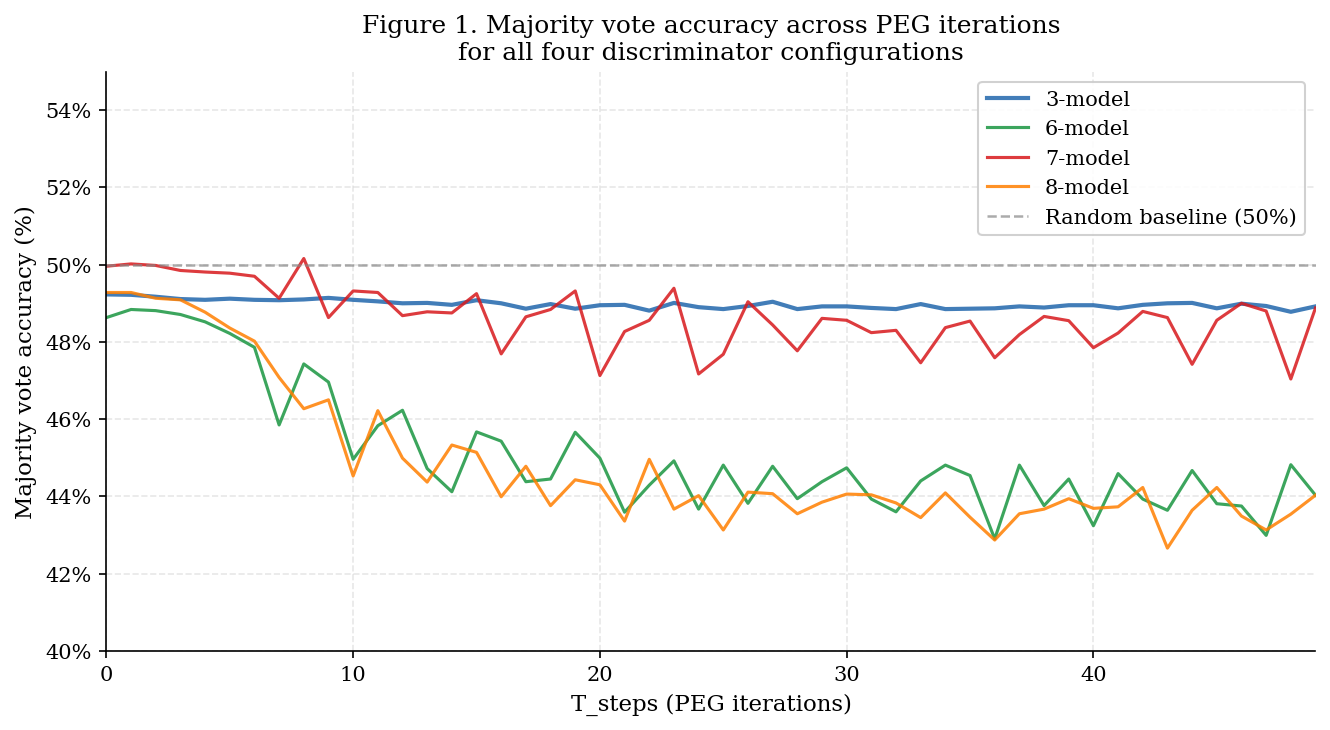


[2/8] Scaling analysis...


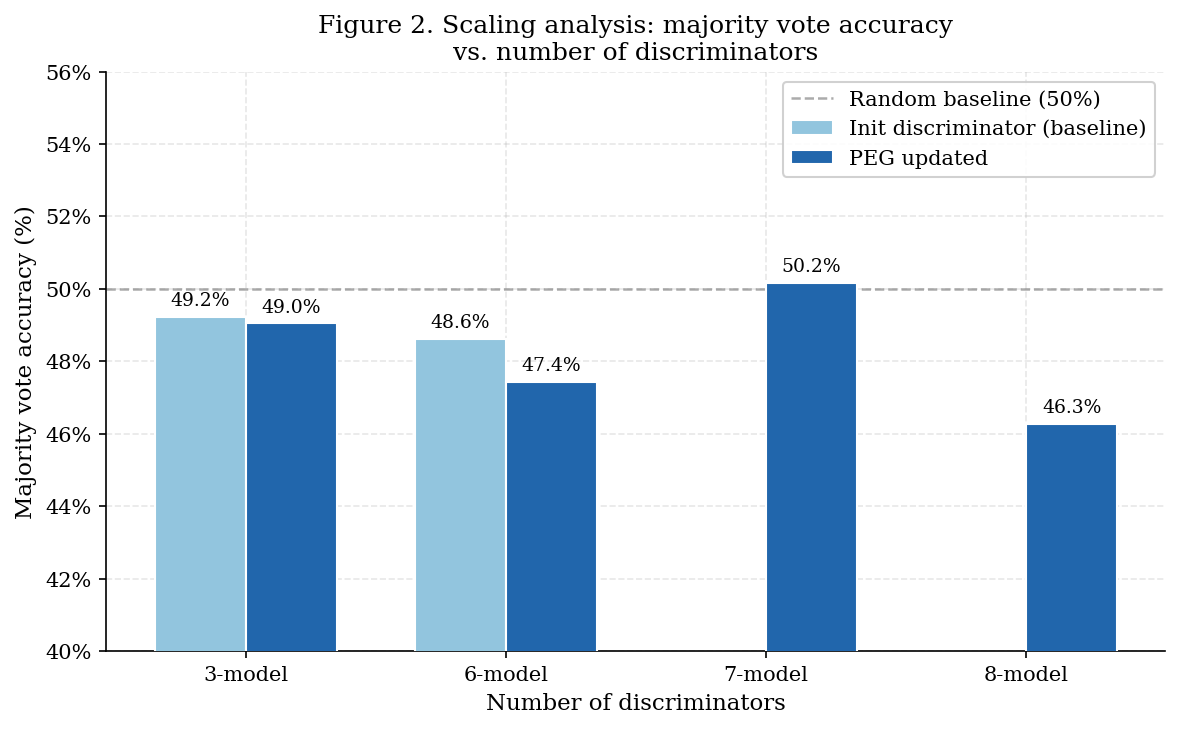


[3/8] Model prediction distributions...


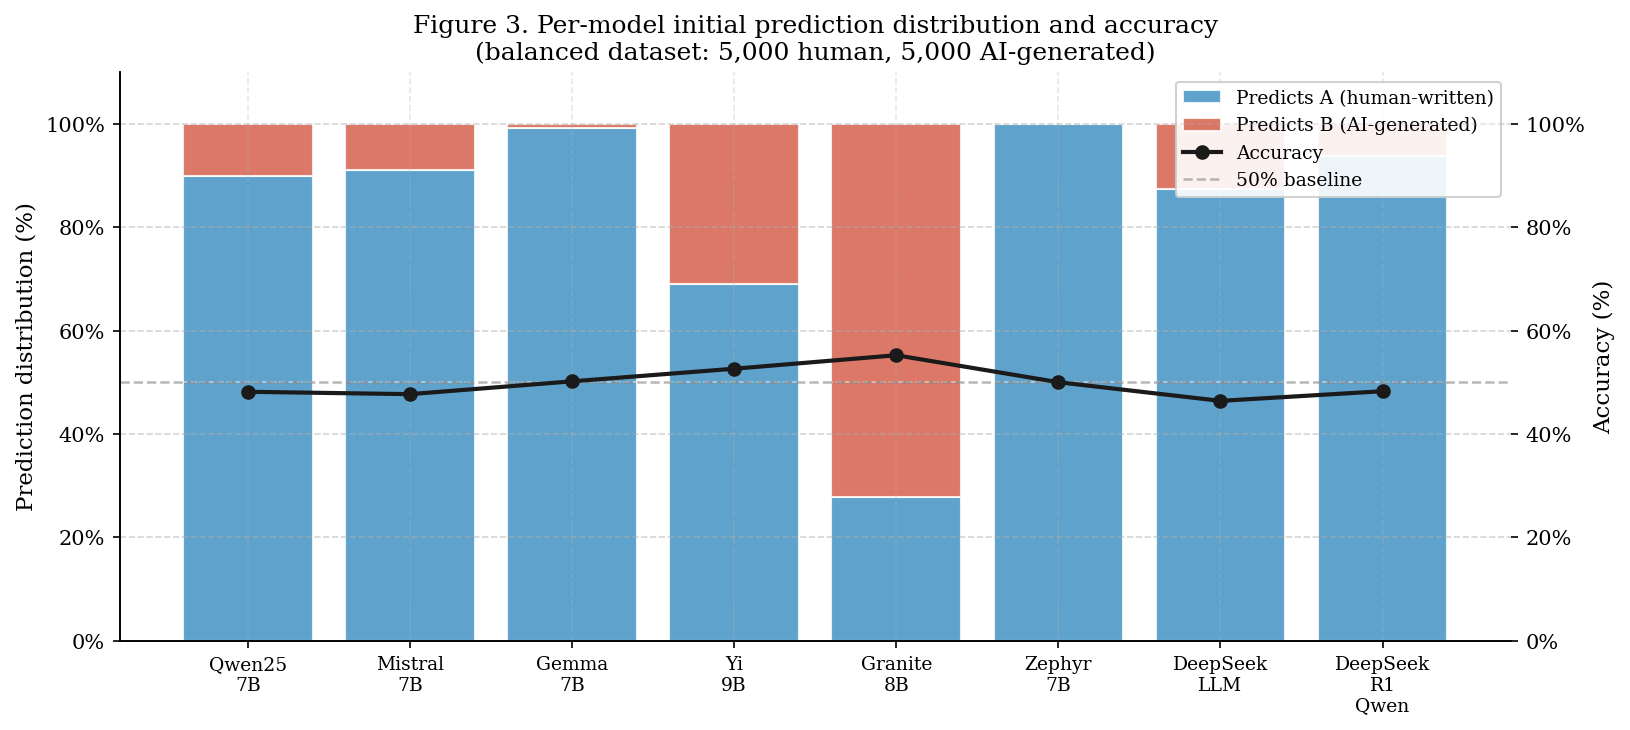


[4/8] Configuration comparison...


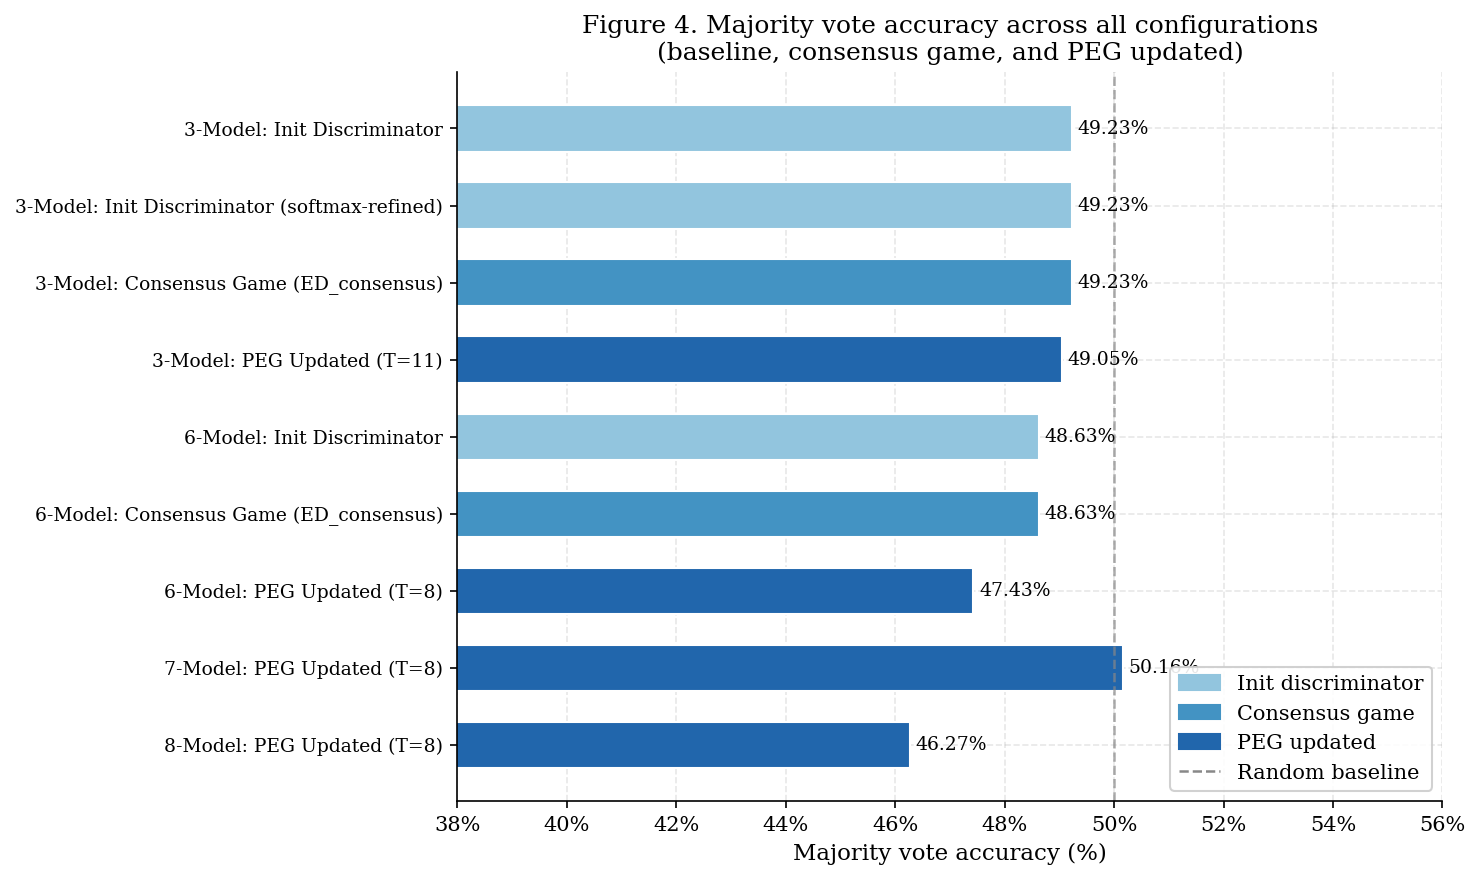


[5/8] Accuracy by true label...


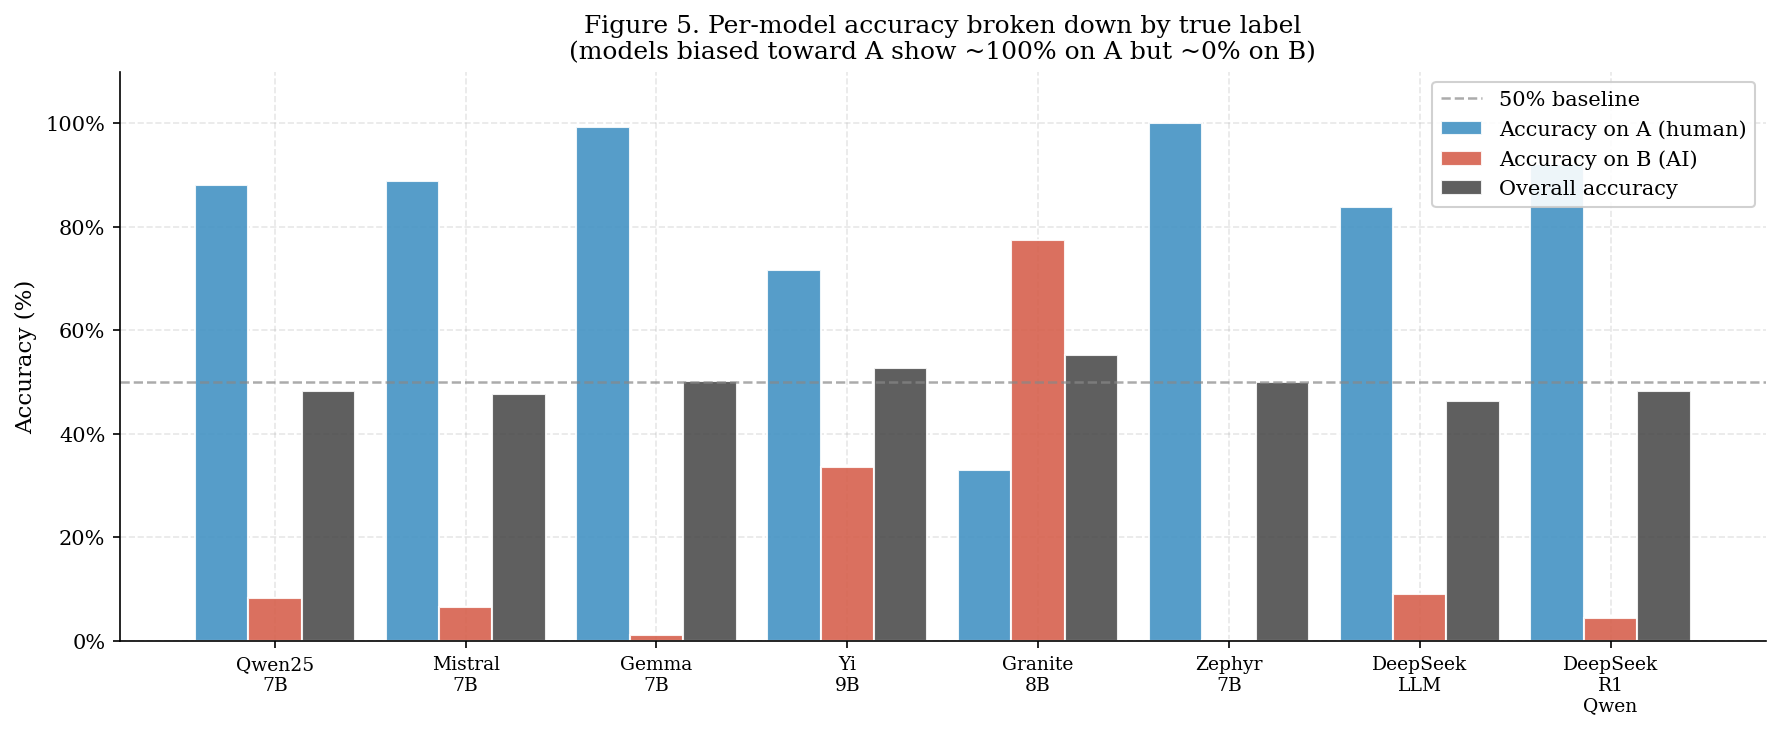


[6/8] Policy entropy...


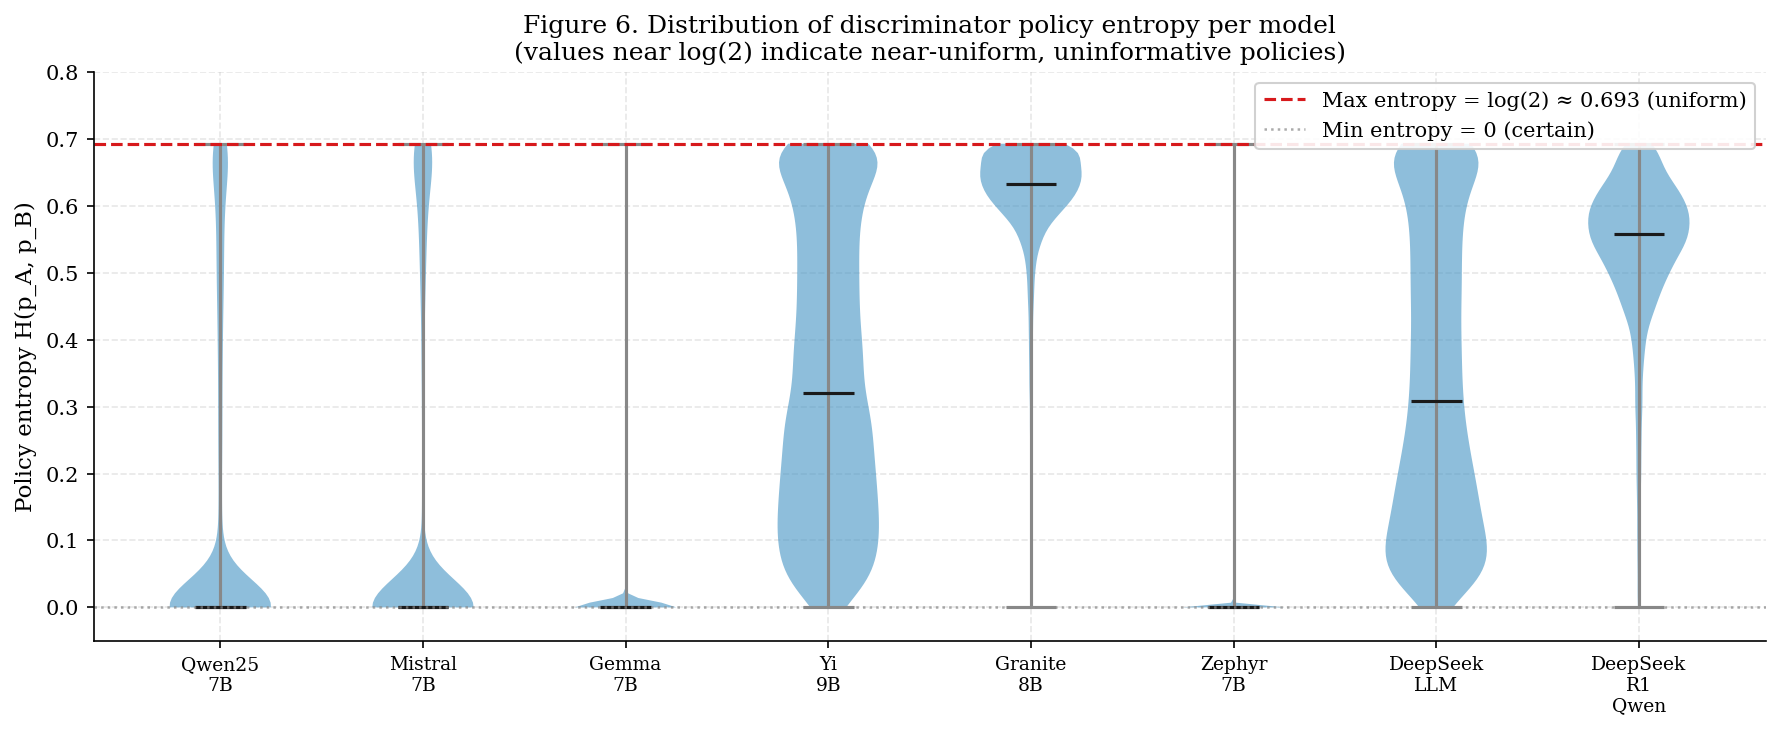


[7/8] Alignment analysis...


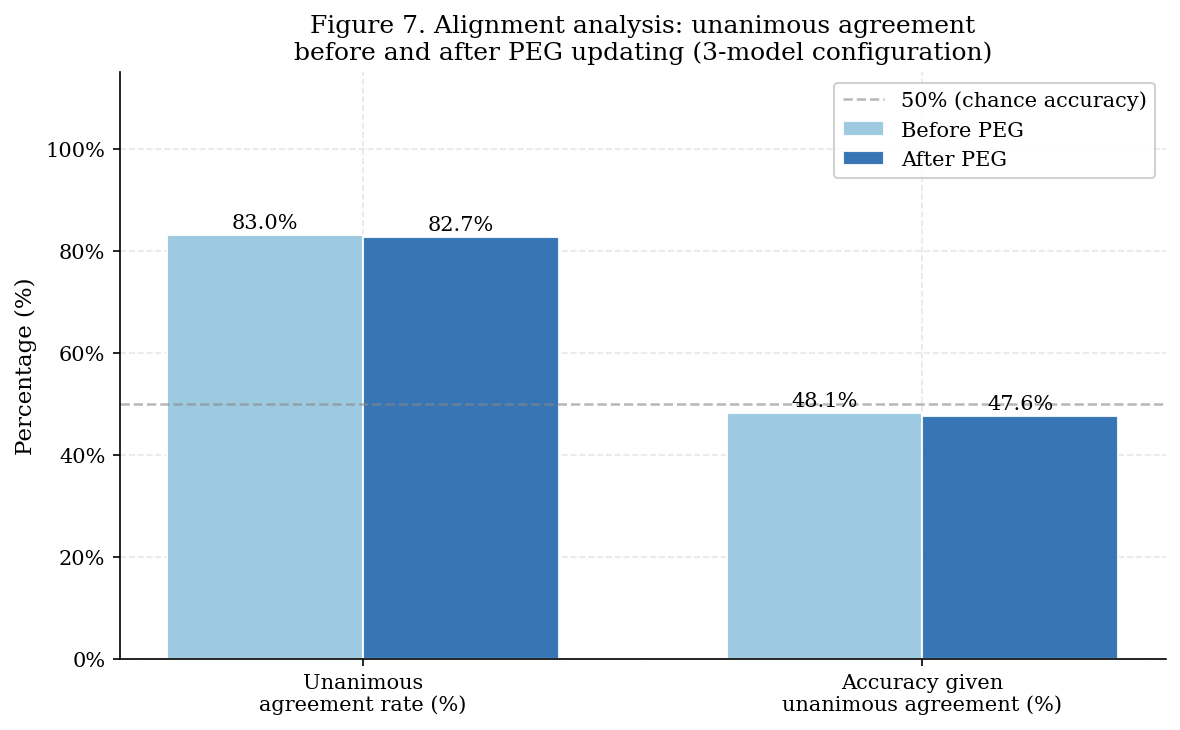


[8/8] Confidence vs. correctness...


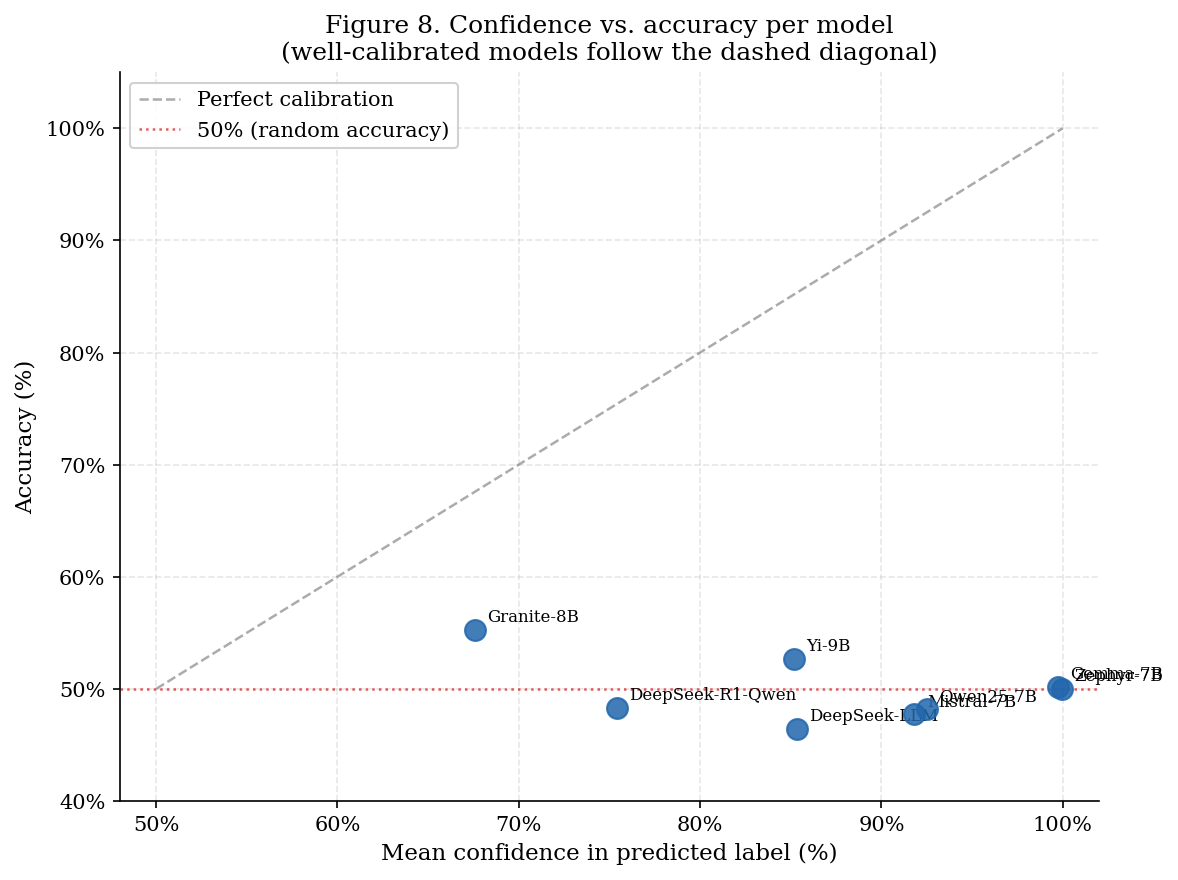


All figures saved to figures/


In [149]:
# ══════════════════════════════════════════════════════════════════════════════
# MASTER CALL — run all figures
# ══════════════════════════════════════════════════════════════════════════════
def generate_all_figures():
    """
    Call this once after all PEG mechanism cells have been run.
    Assumes all required variables are in the notebook namespace.
    """
    print("Generating all results figures...")
    print("="*55)

    # Build the 8-model dict for per-model analysis
    model_dfs_dict = {
        "Qwen25_7B":       df_qwen,
        "Mistral_7B":      df_mistral,
        "Gemma_7B":        df_gemma,
        "Yi_9B":           df_yi,
        "Granite_8B":      df_granite,
        "Zephyr_7B":       df_zephyr,
        "DeepSeek_LLM":    df_deepseek_llm,
        "DeepSeek_R1_Qwen":df_deepseek_qwen,
    }

    print("\n[1/8] Iteration sweep...")
    plot_iteration_sweep(plot_df_all)

    print("\n[2/8] Scaling analysis...")
    plot_scaling_analysis(
        results_3_peg, results_6_peg, results_7_peg, results_8_peg,
        results_3_init_dis, results_6_init_dis
    )

    print("\n[3/8] Model prediction distributions...")
    plot_model_distributions(model_dfs_dict, label_col='answer_letter')

    print("\n[4/8] Configuration comparison...")
    plot_configuration_comparison(comparison)

    print("\n[5/8] Accuracy by true label...")
    plot_accuracy_by_label(model_dfs_dict, label_col='answer_letter')

    print("\n[6/8] Policy entropy...")
    plot_policy_entropy(model_dfs_dict)

    print("\n[7/8] Alignment analysis...")
    plot_alignment_analysis(
        discriminator_3dict,
        discriminator_3dict_update,
        label_col='answer_letter'
    )

    print("\n[8/8] Confidence vs. correctness...")
    plot_confidence_vs_correctness(model_dfs_dict, label_col='answer_letter')

    print("\n" + "="*55)
    print("All figures saved to figures/")
    print("="*55)


# ── Run ────────────────────────────────────────────────────────────────────────
generate_all_figures()

## Assumption 1

In [57]:
import numpy as np
import pandas as pd
from scipy.stats import entropy
import matplotlib.pyplot as plt
import ast, re

In [ ]:
# find accuracy of initial answer vs ground truth, mean confidence, entropy, and accuracy
def analyze_initial_policies(model_dfs: dict, label_col = 'answer_letter'):
    """
    For each model, compute:
    - Accuracy of disc_init_answer vs. ground truth
    - Mean confidence P(predicted label) — how certain is the model?
    - Mean confidence P(correct label) — does high confidence track correctness?
    - Policy entropy — is the model uncertain or near-deterministic?
    - Accuracy broken down by true label (A and B separately)
    """
    rows = []
    for name, df in model_dfs.items():
        df = df.copy()
        df['disc_init_policy_parsed'] = df['disc_init_policy'].apply(parse_policy)

        # Extract p_A and p_B
        df['p_A'] = df['disc_init_policy_parsed'].apply(
            lambda x: x.get('A', {}).get('correct', 0.5) if x else 0.5
        )
        df['p_B'] = df['disc_init_policy_parsed'].apply(
            lambda x: x.get('B', {}).get('correct', 0.5) if x else 0.5
        )

        # policy entropy
        df['policy_entropy'] = df.apply(
            lambda r: entropy([r['p_A'], r['p_B']]), axis=1
        )

        # predicted label and correctness
        df['predicted'] = df.apply(
            lambda r: 'A' if r['p_A'] > r['p_B'] else 'B', axis=1
        )
        df['correct'] = df['predicted'] == df[label_col]

        # confidence in predicted label
        df['p_predicted'] = df.apply(
            lambda r: r['p_A'] if r['predicted'] == 'A' else r['p_B'], axis=1
        )

        # confidence in the true label
        df['p_true'] = df.apply(
            lambda r: r['p_A'] if r[label_col] == 'A' else r['p_B'], axis=1
        )

        # accuracy by true label
        acc_A = df[df[label_col] == 'A']['correct'].mean()
        acc_B = df[df[label_col] == 'B']['correct'].mean()

        rows.append({
            'Model': name,
            'Overall Accuracy': f"{df['correct'].mean():.4f}",
            'Accuracy on A (human)': f"{acc_A:.4f}",
            'Accuracy on B (AI)': f"{acc_B:.4f}",
            'Mean Confidence (predicted)': f"{df['p_predicted'].mean():.4f}",
            'Mean P(true label)': f"{df['p_true'].mean():.4f}",
            'Mean Policy Entropy': f"{df['policy_entropy'].mean():.4f}",
            'A-prediction rate': f"{(df['predicted'] == 'A').mean():.4f}",
        })

    results = pd.DataFrame(rows)
    display(results)
    return results

In [95]:
# calibration plot
def plot_calibration(model_dfs: dict, label_col = 'answer_letter', n_bins = 10):
    """
    For each model, plot mean accuracy within confidence bins.
    A well-calibrated model predicts correctly ~X% of the time
    when its confidence is X%. A biased model shows a flat line near 0 or 1.
    """
    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    axes = axes.flatten()

    for idx, (name, df) in enumerate(model_dfs.items()):
        df = df.copy()
        df['disc_init_policy_parsed'] = df['disc_init_policy'].apply(parse_policy)
        df['p_A'] = df['disc_init_policy_parsed'].apply(
            lambda x: x.get('A', {}).get('correct', 0.5) if x else 0.5
        )
        df['p_B'] = df['disc_init_policy_parsed'].apply(
            lambda x: x.get('B', {}).get('correct', 0.5) if x else 0.5
        )
        df['predicted'] = df.apply(lambda r: 'A' if r['p_A'] > r['p_B'] else 'B', axis=1)
        df['correct'] = (df['predicted'] == df[label_col]).astype(int)
        df['p_predicted'] = df.apply(
            lambda r: r['p_A'] if r['predicted'] == 'A' else r['p_B'], axis = 1
        )

        bins = np.linspace(0.5, 1.0, n_bins + 1)
        bin_acc, bin_centers = [], []
        for i in range(len(bins) - 1):
            mask = (df['p_predicted'] >= bins[i]) & (df['p_predicted'] < bins[i+1])
            if mask.sum() > 0:
                bin_acc.append(df.loc[mask, 'correct'].mean())
                bin_centers.append((bins[i] + bins[i+1]) / 2)

        ax = axes[idx]
        ax.plot([0.5, 1.0], [0.5, 1.0], 'k--', alpha = 0.4, label = 'Perfect calibration')
        ax.plot(bin_centers, bin_acc, 'o-', color = 'steelblue', label = 'Model')
        ax.set_title(name, fontsize = 11)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Accuracy')
        ax.set_xlim(0.5, 1.0)
        ax.set_ylim(0.0, 1.0)
        ax.legend(fontsize = 8)
        ax.grid(True, alpha = 0.3)

    plt.suptitle('Calibration Analysis: Confidence vs. Accuracy per Model', fontsize=13)
    plt.tight_layout()
    plt.savefig('Figures/assumption1_calibration.png', dpi = 150, bbox_inches = 'tight')
    plt.show()

=== Assumption 1: Initial Policy Informativeness ===


,Model,Overall Accuracy,Accuracy on A (human),Accuracy on B (AI),Mean Confidence (predicted),Mean P(true label),Mean Policy Entropy,A-prediction rate
0,Qwen25_7B,0.4818,0.8806,0.0830,0.9250,0.4760,0.1537,0.8988
1,Mistral_7B,0.4772,0.8884,0.0660,0.9182,0.4749,0.1557,0.9112
2,Gemma_7B,0.5020,0.9932,0.0108,0.9974,0.5018,0.0068,0.9912
3,Yi_9B,0.5264,0.7170,0.3358,0.8516,0.5187,0.3468,0.6906
4,Granite_8B,0.5525,0.3302,0.7748,0.6756,0.5169,0.6094,0.2777
5,Zephyr_7B,0.5003,0.9998,0.0008,0.9997,0.5003,0.0007,0.9995
6,DeepSeek_LLM,0.4642,0.8386,0.0898,0.8534,0.4659,0.3384,0.8744
7,DeepSeek_R1_Qwen,0.4829,0.9216,0.0442,0.7542,0.4959,0.5332,0.9387


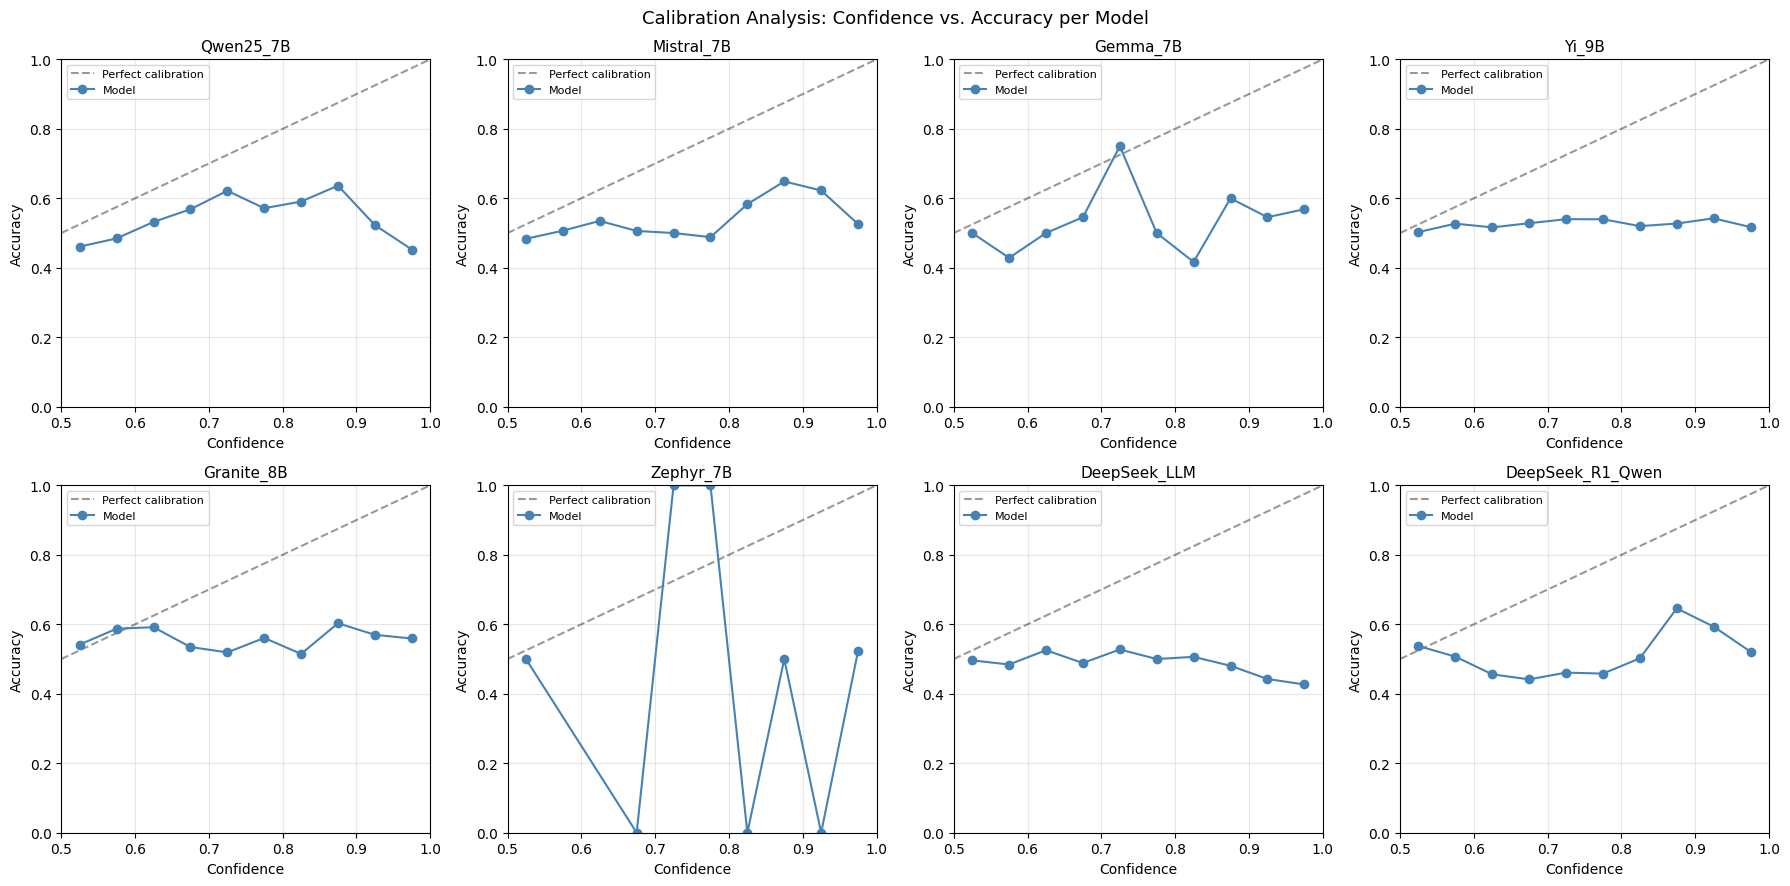

In [97]:
results_1 = analyze_initial_policies(discriminator_8dict, label_col='answer_letter')
plot_calibration(discriminator_8dict, label_col='answer_letter')

## Assumption 2

In [73]:
from itertools import combinations

# find pairwise agreement rates
def pairwise_agreement_analysis(model_dfs: dict, answer_col='disc_init_refine_answer',
                                 label_col='answer_letter'):
    """
    For every pair of models, compute:
    - Raw agreement rate (% of samples where both predict the same label)
    - Agreement rate on correct predictions (both right)
    - Agreement rate on incorrect predictions (both wrong)

    High agreement on incorrect predictions is the signature of
    correlated bias rather than genuine heterogeneous signal.
    """
    model_names = list(model_dfs.keys())
    base_df = model_dfs[model_names[0]]
    correct_answers = base_df[label_col].values

    preds = {
        name: model_dfs[name][answer_col].values
        for name in model_names
    }

    rows = []
    for m1, m2 in combinations(model_names, 2):
        p1, p2 = preds[m1], preds[m2]

        agree_mask = p1 == p2
        both_correct = (p1 == correct_answers) & (p2 == correct_answers)
        both_wrong = (p1 != correct_answers) & (p2 != correct_answers)
        one_right = ((p1 == correct_answers) & (p2 != correct_answers)) | \
                    ((p1 != correct_answers) & (p2 == correct_answers))

        rows.append({
            'Model 1': m1,
            'Model 2': m2,
            'Agreement Rate': f"{agree_mask.mean():.4f}",
            'Both Correct': f"{both_correct.mean():.4f}",
            'Both Wrong': f"{both_wrong.mean():.4f}",
            'Disagree (one right)': f"{one_right.mean():.4f}",
        })

    results = pd.DataFrame(rows)
    display(results)
    return results

In [75]:
# inter-rater reliability
def fleiss_kappa(model_dfs: dict, answer_col = 'disc_init_refine_answer'):
    """
    Computes Fleiss' kappa across all models.
    kappa = 0: agreement no better than chance
    kappa = 1: perfect agreement
    kappa < 0: worse than chance (systematic disagreement)

    For PEG to work well, kappa should be moderate but not too high.
    Too high = correlated bias. Too low = pure noise.
    We want kappa reflecting genuine content-dependent disagreement.
    """
    model_names = list(model_dfs.keys())
    n_models = len(model_names)
    n_samples = len(model_dfs[model_names[0]])
    categories = ['A', 'B']
    n_cats = len(categories)

    # build rating matrix: rows = samples, cols = categories, values = count of raters
    rating_matrix = np.zeros((n_samples, n_cats))
    for name in model_names:
        preds = model_dfs[name][answer_col].values
        for i, pred in enumerate(preds):
            if pred == 'A':
                rating_matrix[i, 0] += 1
            elif pred == 'B':
                rating_matrix[i, 1] += 1

    # Fleiss' kappa computation
    n = n_models
    N = n_samples
    k = n_cats

    P_i = (1 / (n * (n - 1))) * (
        np.sum(rating_matrix ** 2, axis=1) - n
    )
    P_bar = P_i.mean()
    p_j = rating_matrix.sum(axis=0) / (N * n)
    P_e_bar = np.sum(p_j ** 2)

    kappa = (P_bar - P_e_bar) / (1 - P_e_bar)

    print(f"  Fleiss' kappa: {kappa:.4f}")
    print(f"\n  Category proportions: A={p_j[0]:.4f}, B={p_j[1]:.4f}")
    print(f"  P_bar (mean agreement beyond chance): {P_bar:.4f}")
    print(f"  P_e_bar (expected agreement by chance): {P_e_bar:.4f}")
    return kappa

In [77]:
# disagreement heatmap
def disagreement_heatmap(model_dfs: dict, answer_col = 'disc_init_refine_answer'):
    """
    Visualizes pairwise disagreement rates as a heatmap.
    High off-diagonal values = models frequently disagree.
    Low off-diagonal values = models mostly agree (correlated bias).
    """
    model_names = list(model_dfs.keys())
    n = len(model_names)
    matrix = np.zeros((n, n))

    preds = {name: model_dfs[name][answer_col].values for name in model_names}

    for i, m1 in enumerate(model_names):
        for j, m2 in enumerate(model_names):
            matrix[i, j] = (preds[m1] != preds[m2]).mean()

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(matrix, cmap='RdYlGn_r', vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(model_names, fontsize=9)

    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{matrix[i,j]:.2f}", ha='center', va='center',
                    fontsize = 8, color = 'black')

    plt.colorbar(im, ax = ax, label='Disagreement Rate')
    ax.set_title('Pairwise Disagreement Rate Between Models\n(0 = always agree, 1 = always disagree)',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig('Figures/assumption2_disagreement_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

,Model 1,Model 2,Agreement Rate,Both Correct,Both Wrong,Disagree (one right)
0,Qwen25_7B,Mistral_7B,0.8614,0.4103,0.4511,0.1386
1,Qwen25_7B,Gemma_7B,0.8940,0.4390,0.4550,0.1060
2,Qwen25_7B,Yi_9B,0.6402,0.3244,0.3158,0.3598
3,Qwen25_7B,Granite_8B,0.2428,0.1386,0.1042,0.7572
4,Qwen25_7B,Zephyr_7B,0.8995,0.4409,0.4586,0.1005
5,Qwen25_7B,DeepSeek_LLM,0.8259,0.3859,0.4400,0.1741
6,Qwen25_7B,DeepSeek_R1_Qwen,0.8834,0.4242,0.4592,0.1166
7,Mistral_7B,Gemma_7B,0.9044,0.4418,0.4626,0.0956
8,Mistral_7B,Yi_9B,0.6190,0.3114,0.3076,0.3810
9,Mistral_7B,Granite_8B,0.2230,0.1263,0.0967,0.7770


  Fleiss' kappa: -0.0616

  Category proportions: A=0.8235, B=0.1765
  P_bar (mean agreement beyond chance): 0.6914
  P_e_bar (expected agreement by chance): 0.7093


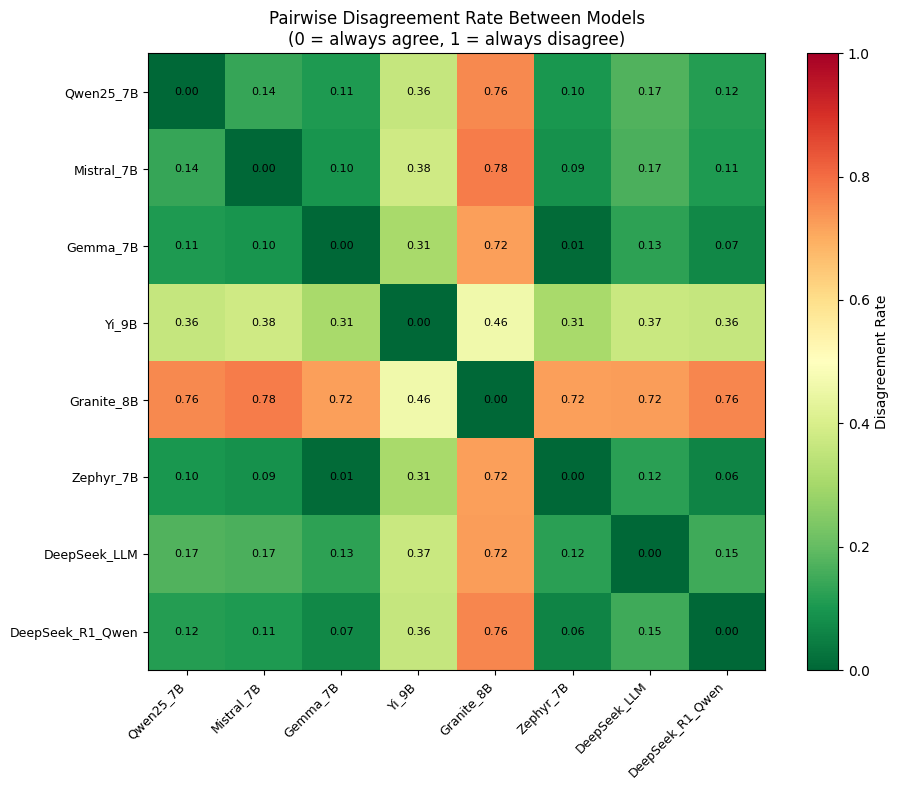

In [79]:
results_2 = pairwise_agreement_analysis(discriminator_8dict,
                                         answer_col='disc_init_refine_answer',
                                         label_col='answer_letter')
kappa = fleiss_kappa(discriminator_8dict, answer_col='disc_init_refine_answer')
disagreement_heatmap(discriminator_8dict, answer_col='disc_init_refine_answer')

## Assumption 3

In [82]:
from itertools import combinations

# DMI inspection
def inspect_dmi_payments(model_dfs: dict, answer_col='disc_init_refine_answer',
                          batch_size = 8, n_batches = 50, random_seed = 213):
    """
    Directly simulate the DMI payment computation on real data and inspect:
    - Distribution of det(M1) * det(M2) across batches
    - How often det = 0 (degenerate batches)
    - Mean, std, min, max of payments per discriminator
    - Whether payments correlate with model accuracy

    This directly tests whether the reward signal is informative
    or collapses to zero due to degenerate co-report matrices.
    """
    np.random.seed(random_seed)
    model_names = list(model_dfs.keys())
    n_discriminators = len(model_names)
    n_samples = len(model_dfs[model_names[0]])
    label_to_index = {'correct': 0, 'incorrect': 1}

    # Get predictions for all models
    preds = {
        name: model_dfs[name][answer_col].values
        for name in model_names
    }

    # choose a fixed reference choice (simulate what batch_update_discriminators does)
    # use the first model's argmax as the choice selector
    choices_all = model_dfs[model_names[0]][answer_col].values

    all_payments = {name: [] for name in model_names}
    det_values = []
    zero_det_count = 0
    total_pairs = 0

    for batch_idx in range(n_batches):
        # sample a batch
        start = (batch_idx * batch_size) % (n_samples - batch_size)
        batch_indices = list(range(start, start + batch_size))

        # build responses: 'correct' if prediction matches choice, else 'incorrect'
        batch_responses = []
        for j in batch_indices:
            choice = choices_all[j]
            task_responses = []
            for name in model_names:
                pred  = preds[name][j]
                task_responses.append('correct' if pred == choice else 'incorrect')
            batch_responses.append(task_responses)

        # split in half
        n = len(batch_responses)
        split1 = batch_responses[:(n + 1) // 2]
        split2 = batch_responses[(n + 1) // 2:]

        # compute DMI for each pair
        dmi_dict = {i: 0.0 for i in range(n_discriminators)}

        for i, j in combinations(range(n_discriminators), 2):
            total_pairs += 1

            def build_matrix(split):
                M = np.zeros((2, 2), dtype=int)
                for row in split:
                    ri = label_to_index[row[i]]
                    rj = label_to_index[row[j]]
                    M[ri][rj] += 1
                return M

            M1 = build_matrix(split1)
            M2 = build_matrix(split2)
            d1 = np.linalg.det(M1)
            d2 = np.linalg.det(M2)
            dmi = d1 * d2

            det_values.append(dmi)
            if abs(dmi) < 1e-10:
                zero_det_count += 1

            dmi_dict[i] += dmi
            dmi_dict[j] += dmi

        for idx, name in enumerate(model_names):
            all_payments[name].append(dmi_dict[idx])

    # Summary statistics
    det_array = np.array(det_values)
    print(f"\nTotal batches evaluated: {n_batches}")
    print(f"Batch size: {batch_size}")
    print(f"Total discriminator pairs: {total_pairs}")
    print(f"\n  DMI det(M1)*det(M2) statistics:")
    print(f"Mean: {det_array.mean():.6f}")
    print(f"Std: {det_array.std():.6f}")
    print(f"Min: {det_array.min():.6f}")
    print(f"Max: {det_array.max():.6f}")
    print(f"% zero: {100 * zero_det_count / total_pairs:.2f}%")

    print(f"\n  Per-discriminator mean payment:")
    for name in model_names:
        payments = np.array(all_payments[name])
        print(f" {name}: mean={payments.mean():.4f}, std={payments.std():.4f}")

    # Plot distribution of DMI values
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(det_array[np.abs(det_array) > 1e-10], bins = 50,
                 color = 'steelblue', edgecolor = 'white', alpha = 0.8)
    axes[0].axvline(0, color='red', linestyle='--', label='Zero reward')
    axes[0].set_title('Distribution of Non-Zero DMI Scores\n(det(M1) × det(M2))', fontsize = 11)
    axes[0].set_xlabel('DMI Score')
    axes[0].set_ylabel('Count')
    axes[0].legend()
    axes[0].grid(True, alpha = 0.3)

    payment_means = [np.array(all_payments[n]).mean() for n in model_names]
    axes[1].bar(model_names, payment_means, color = 'steelblue', edgecolor = 'white')
    axes[1].axhline(0, color = 'red', linestyle = '--')
    axes[1].set_title('Mean DMI Payment per Discriminator', fontsize = 11)
    axes[1].set_ylabel('Mean Payment')
    axes[1].set_xticklabels(model_names, rotation = 45, ha = 'right', fontsize = 9)
    axes[1].grid(True, alpha = 0.3)

    plt.tight_layout()
    plt.savefig('Figures/assumption3_dmi_payments.png', dpi = 150, bbox_inches = 'tight')
    plt.show()
    return all_payments


Total batches evaluated: 100
Batch size: 8
Total discriminator pairs: 2800

  DMI det(M1)*det(M2) statistics:
Mean: 0.328571
Std: 1.867362
Min: -9.000000
Max: 16.000000
% zero: 89.00%

  Per-discriminator mean payment:
 Qwen25_7B: mean=0.0000, std=0.0000
 Mistral_7B: mean=2.4300, std=7.0046
 Gemma_7B: mean=4.7100, std=10.5521
 Yi_9B: mean=1.8500, std=6.2472
 Granite_8B: mean=0.1200, std=3.6367
 Zephyr_7B: mean=4.6800, std=10.4956
 DeepSeek_LLM: mean=2.0300, std=7.0420
 DeepSeek_R1_Qwen: mean=2.5800, std=9.1958


C:\Users\Chris\AppData\Local\Temp\ipykernel_13820\1149644352.py:121: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(model_names, rotation = 45, ha = 'right', fontsize = 9)


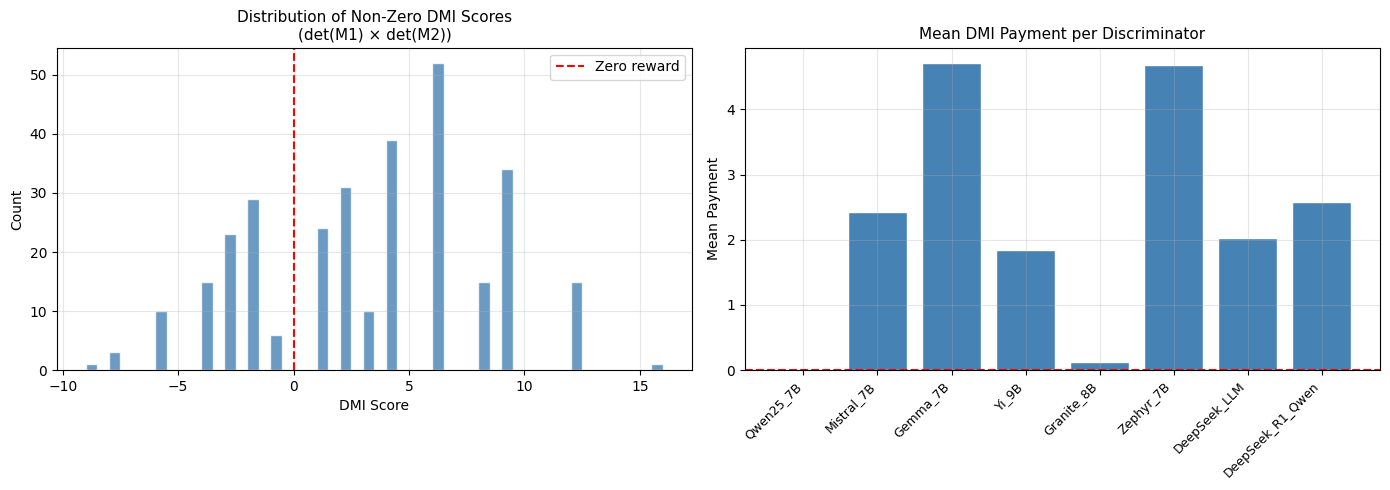

In [84]:
payments = inspect_dmi_payments(discriminator_8dict, answer_col = 'disc_init_refine_answer', batch_size = 8, n_batches = 100)

## Assumption 4

In [87]:
# policy distribution before and after PEG
def analyze_policy_shift(discriminator_dfs_before: dict,
                          discriminator_dfs_after: dict,
                          label_col = 'answer_letter'):
    """
    Compares each model's policy distribution before and after PEG updating.

    If PEG is working, we expect:
    - P(correct label) to increase after updating
    - Policy entropy to decrease (more confident, more decisive)
    - KL divergence from initial policy to be meaningful (policies actually changed)

    If PEG is NOT working, we expect:
    - Little or no change in accuracy
    - KL divergence near zero (policies barely moved)
    - No systematic shift toward the correct label
    """
    rows = []
    for name in discriminator_dfs_before.keys():
        df_before = discriminator_dfs_before[name].copy()
        df_after = discriminator_dfs_after[name].copy()

        # Parse policies
        df_before['policy_parsed'] = df_before['disc_init_policy'].apply(parse_policy)
        df_before['p_A_before'] = df_before['policy_parsed'].apply(
            lambda x: x.get('A', {}).get('correct', 0.5) if x else 0.5
        )
        df_before['p_B_before'] = 1 - df_before['p_A_before']

        # After: parse updated_disc_policy
        df_after['updated_policy_parsed'] = df_after['updated_disc_policy'].apply(parse_policy)
        df_after['p_A_after'] = df_after['updated_policy_parsed'].apply(
            lambda x: x.get('A', {}).get('correct', 0.5) if x else 0.5
        )
        df_after['p_B_after'] = 1 - df_after['p_A_after']

        # accuracy before and after
        correct_answers = df_before[label_col].values
        pred_before = np.where(df_before['p_A_before'] > 0.5, 'A', 'B')
        pred_after  = np.where(df_after['p_A_after']  > 0.5, 'A', 'B')

        acc_before = (pred_before == correct_answers).mean()
        acc_after  = (pred_after  == correct_answers).mean()

        # mean P(true label) before and after
        p_true_before = np.where(
            correct_answers == 'A',
            df_before['p_A_before'],
            df_before['p_B_before']
        ).mean()
        
        p_true_after = np.where(
            correct_answers == 'A',
            df_after['p_A_after'],
            df_after['p_B_after']
        ).mean()

        # KL divergence from before to after (mean over samples)
        eps = 1e-10
        p_before = np.column_stack([df_before['p_A_before'], df_before['p_B_before']])
        p_after  = np.column_stack([df_after['p_A_after'],   df_after['p_B_after']])
        kl_divs  = np.sum(
            p_after * np.log((p_after + eps) / (p_before + eps)), axis=1
        )

        # entropy before and after
        ent_before = entropy(p_before.T).mean()
        ent_after  = entropy(p_after.T).mean()

        rows.append({
            'Model': name,
            'Accuracy Before': f"{acc_before:.4f}",
            'Accuracy After': f"{acc_after:.4f}",
            'Acc Change': f"{acc_after - acc_before:+.4f}",
            'Mean P(true) Before': f"{p_true_before:.4f}",
            'Mean P(true) After': f"{p_true_after:.4f}",
            'P(true) Change': f"{p_true_after - p_true_before:+.4f}",
            'Mean KL Divergence': f"{kl_divs.mean():.6f}",
            'Entropy Before': f"{ent_before:.4f}",
            'Entropy After': f"{ent_after:.4f}",
        })

    results = pd.DataFrame(rows)
    display(results)
    return results

In [89]:
results_4 = analyze_policy_shift(discriminator_8dict,
                                  discriminator_8dict_update,
                                  label_col='answer_letter')

,Model,Accuracy Before,Accuracy After,Acc Change,Mean P(true) Before,Mean P(true) After,P(true) Change,Mean KL Divergence,Entropy Before,Entropy After
0,Qwen25_7B,0.4818,0.4492,-0.0326,0.4760,0.4780,+0.0020,2.701041,0.1537,0.6052
1,Mistral_7B,0.4772,0.4616,-0.0156,0.4749,0.4866,+0.0117,4.397848,0.1557,0.5578
2,Gemma_7B,0.5020,0.4853,-0.0167,0.5018,0.4992,-0.0025,5.505759,0.0068,0.5585
3,Yi_9B,0.5264,0.5118,-0.0146,0.5187,0.5073,-0.0114,0.344547,0.3468,0.5532
4,Granite_8B,0.5525,0.5666,+0.0141,0.5169,0.5131,-0.0038,0.106816,0.6094,0.5674
5,Zephyr_7B,0.5003,0.4815,-0.0188,0.5003,0.4977,-0.0026,5.997827,0.0007,0.5593
6,DeepSeek_LLM,0.4642,0.4589,-0.0053,0.4659,0.4852,+0.0193,0.384351,0.3384,0.5731
7,DeepSeek_R1_Qwen,0.4829,0.4639,-0.0190,0.4959,0.4977,+0.0018,0.153702,0.5332,0.6089


## Assumption 5

In [91]:
# co-report matric rank and structure analysis
def analyze_coreport_matrices(model_dfs: dict, answer_col='disc_init_refine_answer',
                               batch_size=8, n_batches=100, random_seed=42):
    """
    Examines the structure of co-report matrices to test whether the binary
    label space produces degenerate matrices.

    For a 2x2 co-report matrix:
    - Rank 2 (det != 0): informative, models disagree in structured ways
    - Rank 1 (det = 0):  degenerate, one label dominates or models always agree
    - Rank 0:            all zeros — no data in that split

    Reports:
    - % of rank-2 matrices (the only ones contributing non-zero DMI)
    - % of rank-1 matrices broken down by cause
      (all-A, all-B, perfect agreement, perfect disagreement)
    """
    np.random.seed(random_seed)
    model_names = list(model_dfs.keys())
    n_samples = len(model_dfs[model_names[0]])
    choices_all = model_dfs[model_names[0]][answer_col].values
    label_to_idx = {'correct': 0, 'incorrect': 1}

    preds = {
        name: model_dfs[name][answer_col].values
        for name in model_names
    }

    rank2_count = 0
    rank1_count = 0
    rank0_count = 0
    total = 0

    # Categorize rank-1 causes
    causes = {'all_correct': 0, 'all_incorrect': 0,
              'perfect_agree': 0, 'perfect_disagree': 0, 'other': 0}

    for batch_idx in range(n_batches):
        start = (batch_idx * batch_size) % (n_samples - batch_size)
        batch_indices = list(range(start, start + batch_size))

        batch_responses = []
        for j in batch_indices:
            choice = choices_all[j]
            task_responses = []
            for name in model_names:
                pred = preds[name][j]
                task_responses.append('correct' if pred == choice else 'incorrect')
            batch_responses.append(task_responses)

        n = len(batch_responses)
        split1 = batch_responses[:(n + 1) // 2]
        split2 = batch_responses[(n + 1) // 2:]

        for i, j in combinations(range(len(model_names)), 2):
            for split in [split1, split2]:
                M = np.zeros((2, 2), dtype=int)
                for row in split:
                    ri = label_to_idx[row[i]]
                    rj = label_to_idx[row[j]]
                    M[ri][rj] += 1

                rank = np.linalg.matrix_rank(M)
                total += 1

                if rank == 2:
                    rank2_count += 1
                elif rank == 1:
                    rank1_count += 1
                    # Diagnose why rank=1
                    if M[1, 0] == 0 and M[1, 1] == 0 and M[0, 1] == 0:
                        causes['all_correct'] += 1
                    elif M[0, 0] == 0 and M[0, 1] == 0 and M[1, 0] == 0:
                        causes['all_incorrect'] += 1
                    elif M[0, 1] == 0 and M[1, 0] == 0:
                        causes['perfect_agree'] += 1
                    elif M[0, 0] == 0 and M[1, 1] == 0:
                        causes['perfect_disagree'] += 1
                    else:
                        causes['other'] += 1
                else:
                    rank0_count += 1

    print(f"\nTotal matrices analyzed: {total}")
    print(f"Rank-2 (informative): {rank2_count} ({100*rank2_count/total:.2f}%)")
    print(f"Rank-1 (degenerate): {rank1_count} ({100*rank1_count/total:.2f}%)")
    print(f"Rank-0 (empty): {rank0_count} ({100*rank0_count/total:.2f}%)")
    print(f"\nRank-1 cause breakdown:")
    for cause, count in causes.items():
        print(f" {cause:25s}: {count} ({100*count/max(rank1_count,1):.2f}% of rank-1)")

    # Visualize
    labels = ['Rank-2\n(informative)', 'Rank-1\n(degenerate)', 'Rank-0\n(empty)']
    values = [rank2_count, rank1_count, rank0_count]
    colors = ['#2ecc71', '#e74c3c', '#95a5a6']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(labels, [v/total for v in values], color=colors, edgecolor='white')
    axes[0].set_title('Co-Report Matrix Rank Distribution', fontsize=11)
    axes[0].set_ylabel('Proportion of Matrices')
    axes[0].grid(True, alpha=0.3, axis='y')

    cause_labels = list(causes.keys())
    cause_values = [causes[k] for k in cause_labels]
    axes[1].bar(cause_labels, [v/max(rank1_count,1) for v in cause_values],
                color='#e74c3c', edgecolor='white', alpha=0.8)
    axes[1].set_title('Causes of Rank-1 (Degenerate) Matrices', fontsize=11)
    axes[1].set_ylabel('Proportion of Rank-1 Matrices')
    axes[1].set_xticklabels(cause_labels, rotation=30, ha='right', fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('figures/assumption5_matrix_rank.png', dpi=150, bbox_inches='tight')
    plt.show()


Total matrices analyzed: 5600
Rank-2 (informative): 1544 (27.57%)
Rank-1 (degenerate): 4056 (72.43%)
Rank-0 (empty): 0 (0.00%)

Rank-1 cause breakdown:
 all_correct              : 1396 (34.42% of rank-1)
 all_incorrect            : 3 (0.07% of rank-1)
 perfect_agree            : 0 (0.00% of rank-1)
 perfect_disagree         : 223 (5.50% of rank-1)
 other                    : 2434 (60.01% of rank-1)


C:\Users\Chris\AppData\Local\Temp\ipykernel_13820\1254327622.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(cause_labels, rotation=30, ha='right', fontsize=9)


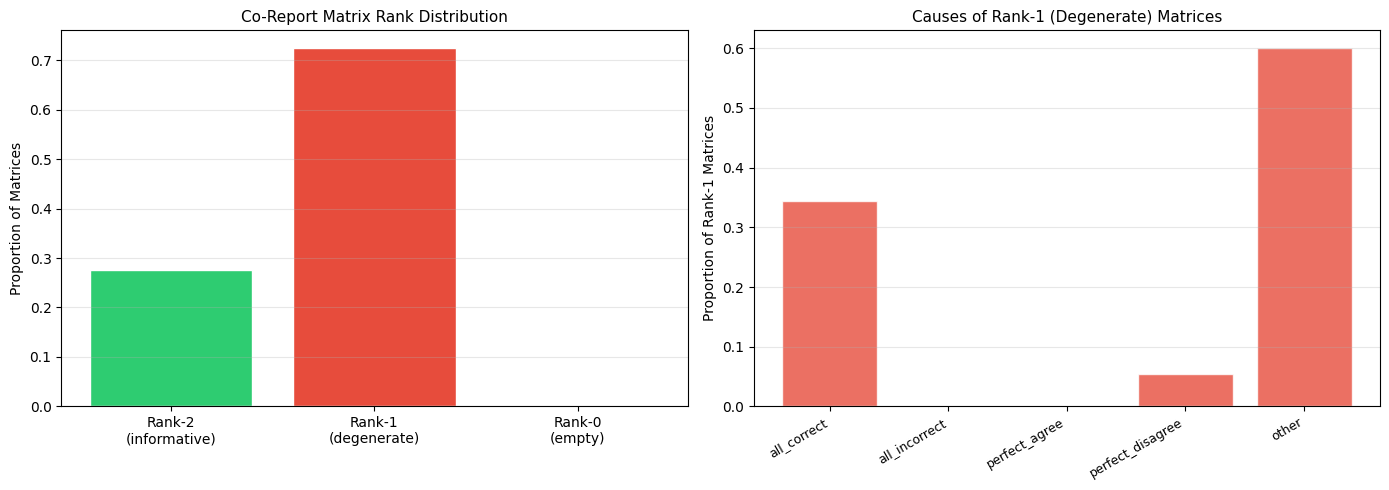

In [93]:
analyze_coreport_matrices(discriminator_8dict,
                           answer_col='disc_init_refine_answer',
                           batch_size=8, n_batches=100)